# MTH 5320 - Homework 1 - Strider Settgast

## Data, Regression, Gradients, Gradient Descent, and Classification

**Deadline**: 5-31-26

**Points**: 60

**Bonus**: up to 5

### Instructions

- Submit **one** Jupyter notebook file and (optionally) **one** PDF with your handwritten work. (Alternatively, type solutions in markdown cells in the notebook.)

    - Your notebook file must include text explanations of your work, well-commented code, and the outputs from your code.

    - All mathematical work must be shown for written/typed problems.

- Use a fixed random seed for randomized experiments.

- For each model, use the usual `sklearn` structure: an initializer for hyperparameters, a `fit` function for training, and a `predict` function for predictions. Use `predict_proba` and `score` when appropriate.

- Do not use `sklearn` model classes for algorithms you are asked to implement from scratch. Datasets, metrics, splitting utilities, and helper functions are allowed.

### Problem 1 — Data Matrices, Targets, and Splits [10 pts]

Use `../data/US_State_Data.csv`.

#### 1A. Load and Describe the Data
Load the data and print the shape, column names, first five rows, and summary statistics. Choose a regression target and a set of feature columns, briefly explaining your choice.

In [23]:
import pandas as pd # data handling
import numpy as np # random number generator + number/data handling
import matplotlib.pyplot as plt # Plotting


df = pd.read_csv('data/US_State_Data.csv') #load data

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns") #print shape
print(f"\nColumn names: \n{df.columns.tolist()}") #print names of columns
print(f"\nFirst five rows: \n{df.head()}") #print first five rows
print(f"\nSummary Statistics: \n{df.describe()}") #print "Summary Statistics"
"""
print regression target ('Expenditure per Student') and feature column selection ("Avg Teacher's Salary", 'Population Density', 'Median Household Income')
"""
print(f"""
For a regression target I would choose expenditure per student
and use population density + average teacher`s salary + median household
income to try to predict it (as feature columns). I would choose these because
it seems like there would be a quantifiable connection between these things
""") 

Shape: 50 rows × 9 columns

Column names: 
['State', 'Crime Rate', 'Violent Crime Rate', "Avg Teacher's Salary", 'Student Teacher Ratio', 'Expenditure per Student', 'Population Density', 'Median Household Income', 'High School Completion']

First five rows: 
        State  Crime Rate  Violent Crime Rate  Avg Teacher's Salary  \
0     Alabama      3605.0               427.4                 49375   
1      Alaska      3395.8               635.8                 65891   
2     Arizona      3597.4               399.9                 45335   
3    Arkansas      3818.1               480.1                 48493   
4  California      2837.2               396.1                 71396   

   Student Teacher Ratio  Expenditure per Student  Population Density  \
0                   15.6                     8797                95.8   
1                    8.7                    20117                 1.3   
2                   17.7                     7461                60.1   
3                    8

#### 1B. Build $X$ and $y$
Create a feature matrix $X$ and target vector $y$. Print their shapes, the first row of $X$, and the first value of $y$. In a sentence or two, explain what one row of $X$ represents.

In [24]:
X = df[['Population Density', "Avg Teacher's Salary", 'Median Household Income']] #create feature matrix
y = df['Expenditure per Student'] #create target vector

print(f"\nFirst row of feature matrix X: \n{X.head(1)}") #print first row of X - the feature matrix
print(f"\nFirst element of target vector y (Expenditure per Student): {y[0]}") #print the first element of y - the target vector
print(f"\nOne row of X represents the Avg Teacher's Salary, Population Density, and Median Household Income of a single state (features of a given instance).\n") #print meaning of a row of X (features of a given instance)


First row of feature matrix X: 
   Population Density  Avg Teacher's Salary  Median Household Income
0                95.8                 49375                    49936

First element of target vector y (Expenditure per Student): 8797

One row of X represents the Avg Teacher's Salary, Population Density, and Median Household Income of a single state (features of a given instance).



#### 1C. Train / Dev / Test Split
Write reusable code to create train/dev/test splits with ratios $(0.6,0.2,0.2)$. Your split should shuffle reproducibly, preserve $X$/$y$ alignment, validate inputs, and return train/dev/test arrays. Print all output shapes.

In [25]:
def train_dev_test_split(X, y, train_ratio=0.6, dev_ratio=0.2, test_ratio=0.2, random_seed=42):
    """
    Split data into train, dev, and test sets.
    
    Parameters:
    X: features array (2D)
    y: target array (1D)
    train_ratio: proportion for training (default 0.6)
    dev_ratio: proportion for development/validation (default 0.2)
    test_ratio: proportion for testing (default 0.2)
    random_seed: for reproducible shuffling
    
    Returns:
    X_train, y_train, X_dev, y_dev, X_test, y_test
    """
    
    # Validate ratios sum to 1
    total = train_ratio + dev_ratio + test_ratio
    if abs(total - 1.0) > 1e-10:
        raise ValueError(f"Ratios must sum to 1. Got {train_ratio} + {dev_ratio} + {test_ratio} = {total}")
    
    # Get number of samples
    n_samples = len(X)
    
    # Set random seed for reproducibility
    np.random.seed(random_seed)
    
    # Create shuffled indices
    indices = np.random.permutation(n_samples)
    
    # Calculate split sizes
    train_end = int(train_ratio * n_samples)
    dev_end = train_end + int(dev_ratio * n_samples)
    
    # Split indices
    train_idx = indices[:train_end]
    dev_idx = indices[train_end:dev_end]
    test_idx = indices[dev_end:]
    
    # Split the data
    X_train, y_train = X[train_idx], y[train_idx]
    X_dev, y_dev = X[dev_idx], y[dev_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    
    return X_train, y_train, X_dev, y_dev, X_test, y_test

## Use train_dev_test_split() to print all output shapes.

X = df[['Population Density', "Avg Teacher's Salary", 'Median Household Income']].values  #convert to numpy
y = df['Expenditure per Student'].values

# Split the data
X_train, y_train, X_dev, y_dev, X_test, y_test = train_dev_test_split(
    X, y, train_ratio=0.6, dev_ratio=0.2, test_ratio=0.2, random_seed=42
)

# Print all output shapes
print("="*50)
print("Train/Dev/Test Split Results")
print("="*50)
print(f"Original data shapes:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"\nAfter split (60/20/20 with random_seed=42):")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  X_dev shape:   {X_dev.shape}")
print(f"  y_dev shape:   {y_dev.shape}")
print(f"  X_test shape:  {X_test.shape}")
print(f"  y_test shape:  {y_test.shape}")
print(f"\nVerification:")
print(f"  Train samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Dev samples:   {len(X_dev)} ({len(X_dev)/len(X)*100:.0f}%)")
print(f"  Test samples:  {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

Train/Dev/Test Split Results
Original data shapes:
  X: (50, 3)
  y: (50,)

After split (60/20/20 with random_seed=42):
  X_train shape: (30, 3)
  y_train shape: (30,)
  X_dev shape:   (10, 3)
  y_dev shape:   (10,)
  X_test shape:  (10, 3)
  y_test shape:  (10,)

Verification:
  Train samples: 30 (60%)
  Dev samples:   10 (20%)
  Test samples:  10 (20%)


#### 1D. Standardization
Write reusable code to standardize rectangular data. Fit the mean and scale only on the training set, handle zero-variance columns, and transform train/dev/test consistently.

In [26]:
class StandardScaler:
    def __init__(self):
        # Store mean and scale (standard deviation) for each feature
        self.mean_ = None
        self.scale_ = None
    
    def fit(self, X):
        """
        Compute mean and standard deviation from training data.
        
        Parameters:
        X: numpy array of shape (n_samples, n_features)
        """
        # Convert to numpy array if it's not already
        X = np.array(X)
        
        # Compute mean for each feature (along rows, keep dimensions)
        self.mean_ = np.mean(X, axis=0)
        
        # Compute standard deviation for each feature
        # ddof=0 for population std (matches sklearn's StandardScaler)
        self.scale_ = np.std(X, axis=0, ddof=0)
        
        # Handle zero-variance columns (std = 0)
        # If std is 0, set scale to 1 to avoid division by zero
        self.scale_ = np.where(self.scale_ == 0, 1, self.scale_)
        
        return self
    
    def transform(self, X):
        """
        Apply standardization using stored mean and scale.
        
        Parameters:
        X: numpy array of shape (n_samples, n_features)
        
        Returns:
        X_scaled: standardized array
        """
        # Check if fit has been called
        if self.mean_ is None or self.scale_ is None:
            raise ValueError("Must call fit() before transform()")
        
        # Convert to numpy array
        X = np.array(X)
        
        # Standardize: (X - mean) / scale
        X_scaled = (X - self.mean_) / self.scale_
        
        return X_scaled
    
    def fit_transform(self, X):
        """
        Fit to data and transform it in one step.
        """
        return self.fit(X).transform(X)


### Use StandardScaler object to scale data and print some data:

X = df[['Population Density', "Avg Teacher's Salary", 'Median Household Income']].values #initialize X

# Create and fit the scaler on training data ONLY
scaler = StandardScaler()

# Using the train/dev/test split from 1C:
# Fit on TRAINING data only!
X_train_scaled = scaler.fit_transform(X_train)

# Transform dev and test using the SAME scaler
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = scaler.transform(y_train.reshape(-1, 1))
y_dev_scaled = scaler.transform(y_dev.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.reshape(-1, 1))


# Print poststandardization info
print("\n" + "="*50)
print("After standardization (fit on train only):")
print("="*50)
print(f"\nX_train_scaled first 3 rows:\n{X_train_scaled[:3]}")
print(f"\nTraining set - column means: {np.mean(X_train_scaled, axis=0)}")
print(f"Training set - column stds:  {np.std(X_train_scaled, axis=0)}")
print(f"\nDev set - column means: {np.mean(X_dev_scaled, axis=0)}")
print(f"Test set - column means: {np.mean(X_test_scaled, axis=0)}")


After standardization (fit on train only):

X_train_scaled first 3 rows:
[[ 0.04702896 -0.40472558 -0.27531572]
 [-0.08176404 -0.78735886 -0.53267516]
 [-0.93296871 -0.88292434 -1.49577557]]

Training set - column means: [-1.81336427e-16 -4.62592927e-17 -2.96059473e-16]
Training set - column stds:  [1. 1. 1.]

Dev set - column means: [-0.05337104 -0.18225113  0.02283434]
Test set - column means: [0.72945625 0.46654192 0.75158838]


### Problem 2 — Regression Losses and Explicit Gradients [10 pts]

Use explicit gradients for linear regression. After appending a leading column of ones to the feature matrix, write $X \in \mathbb{R}^{n \times (d+1)}$, $y \in \mathbb{R}^n$, and $w \in \mathbb{R}^{d+1}$. The predictions are $\hat{y}=Xw$ and the loss is $L(w)=\frac{1}{n}\|Xw-y\|_2^2$.


#### 2A. Derive the Gradient
Starting from $L(w)=\frac{1}{n}(Xw-y)^T(Xw-y)$, derive an explicit formula for $\nabla L(w)$.

$\frac{1}{n} \nabla[(Xw-y)^T(Xw-y)]=\frac{1}{n} \nabla[(w^TX^T-y^T)(Xw-y)]=\frac{1}{n} \nabla[w^TX^TXw-y^TXw-w^TX^Ty+y^Ty]$ \
\
note that $y^TXw=(w^TX^Ty)^T$ and $y^Ty$ are scalar elements \
\
$\nabla L(w)$ becomes: \
\
$\frac{1}{n}\nabla[w^TX^TXw-2w^TX^Ty+y^Ty]=\frac{2}{n}(X^TXw-X^Ty) = \frac{2}{n}X^T(Xw-y)$

#### 2B. Implement the Loss and Gradient
Implement code to append the column of ones, compute the MSE loss, and compute the explicit MSE gradient from your formula. In your derivation and code comments, use $X$ for the design matrix after the ones column has been appended.

In [27]:
def append_ones(X_raw):
    n = X_raw.shape[0]
    ones_col = np.ones((n, 1)) #make ones column
    X = np.hstack([ones_col, X_raw]) #horizontal stack
    return X
    
def mse_loss(X, y, w):
    return np.mean((X @ w - y) ** 2)
    
def mse_gradient(X, y, w):
    return (2/X.shape[0])*X.T@(X@w-y) #derived above
    
def mae_loss(X, y, w):
    return np.mean(np.abs(X @ w - y)) #useful for later
    
def r_squared(X, y, w):
    """Calculate R² coefficient of determination."""
    y_pred = X @ w
    
    # Sum of squared residuals (SS_res)
    ss_res = np.sum((y - y_pred) ** 2)
    
    # Sum of squares total (SS_tot)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    
    # R² = 1 - SS_res/SS_tot
    r2 = 1 - (ss_res / ss_tot)
    
    return r2

#### 2C. Check One Gradient Step
Check your implementation on a small synthetic dataset by printing the shapes of $X$, $y$, $w$, and the gradient. Take one small gradient step and show that the loss decreases.

In [28]:
# Append ones to X
X_ones = append_ones(X)
print(f"First 2 rows and columns of X_ones: \n{X_ones[:2,:2]}")
print(X_ones.shape)

# Initialize synthetic data (from subset of census data) X_small, y_small and random weight vector w
X_small = X_ones[:15,:4]
y_small = y[:15].reshape(-1, 1)

np.random.seed(42) 
d = X_small.shape[1]
w_small = np.random.randn(d, 1) 

# Take the gradient and the loss
grad = mse_gradient(X_small, y_small, w_small)
loss = mse_loss(X_small, y_small, w_small)

# Print shapes of synthetic data
print(f"X is of shape: {X_small.shape}")
print(f"y is of shape: {y_small.shape}")
print(f"w is of shape: {w_small.shape}")
print(f"The gradient of the loss function is of shape: {grad.shape}")

# Take one gradient step
alpha = .0000000001 #learning rate
w_new = w_small - alpha * grad

# Compute new loss
loss_new = mse_loss(X_small, y_small, w_new)

# Print loss comparison before and after gradient step
print("\n" + "="*50)
print("Loss before and after a gradient step:")
print("="*50)
print(f"Loss before: {loss:.6f}")
print(f"Loss after:  {loss_new:.6f}")
print(f"Log loss difference:  {np.log(loss-loss_new)}")

First 2 rows and columns of X_ones: 
[[ 1.  95.8]
 [ 1.   1.3]]
(50, 4)
X is of shape: (15, 4)
y is of shape: (15, 1)
w is of shape: (4, 1)
The gradient of the loss function is of shape: (4, 1)

Loss before and after a gradient step:
Loss before: 14978574139.644545
Loss after:  3003706076.981349
Log loss difference:  23.20607596245102


#### 2D. Closed-Form Least Squares
On the standardized state data, compute the closed-form least-squares solution $w=(X^TX)^{-1}X^Ty$ or a stable equivalent. Report train/dev/test MAE, MSE, and $R^2$.

In [29]:
# Append ones to census data groups
X_train_scaled_ones = append_ones(X_train_scaled)
X_dev_scaled_ones = append_ones(X_dev_scaled)
X_test_scaled_ones = append_ones(X_test_scaled)

# Compute w using least squares
w = np.linalg.solve(X_train_scaled_ones.T@X_train_scaled_ones,X_train_scaled_ones.T@y_train_scaled)

# Compute error metrics
MSE_train = mse_loss(X_train_scaled_ones, y_train_scaled, w)
MSE_dev = mse_loss(X_dev_scaled_ones, y_dev_scaled, w)
MSE_test = mse_loss(X_test_scaled_ones, y_test_scaled, w)
MAE_train = mae_loss(X_train_scaled_ones, y_train_scaled, w)
MAE_dev = mae_loss(X_dev_scaled_ones, y_dev_scaled, w)
MAE_test = mae_loss(X_test_scaled_ones, y_test_scaled, w)
R2_train = r_squared(X_train_scaled_ones, y_train_scaled, w)
R2_dev = r_squared(X_dev_scaled_ones, y_dev_scaled, w)
R2_test = r_squared(X_test_scaled_ones, y_test_scaled, w)

# Print error metrics
print("="*70)
print("2D. Closed-Form Least Squares - Results")
print("="*70)

# Header
print(f"\n{'Metric':<15} {'Train':<18} {'Dev':<18} {'Test':<18}")
print("-"*70)

# MAE
print(f"{'MAE':<15} ${MAE_train:>16,.2f} ${MAE_dev:>16,.2f} ${MAE_test:>16,.2f}")

# MSE
print(f"{'MSE':<15} ${MSE_train:>16,.2f} ${MSE_dev:>16,.2f} ${MSE_test:>16,.2f}")

# R Squared
print(f"{'R Squared':<15} {R2_train:>16,.2f} {R2_dev:>16,.2f} {R2_test:>16,.2f}")

print("="*70)

# Also print weights
print("\n" + "="*70)
print("Learned Weights:")
print("="*70)
feature_names = ['Bias', 'Population Density', "Avg Teacher's Salary", 'Median Household Income']
for name, weight in zip(feature_names, w.flatten()):
    print(f"  {name:25}: {weight:12.4f}")
print("="*70)

2D. Closed-Form Least Squares - Results

Metric          Train              Dev                Test              
----------------------------------------------------------------------
MAE             $            3.50 $            3.89 $            4.07
MSE             $           84.55 $           65.26 $           71.33
R Squared                   0.94             0.96             0.96

Learned Weights:
  Bias                     :      67.4549
  Population Density       :      -5.1818
  Avg Teacher's Salary     :      -5.3419
  Median Household Income  :       0.2911


### Problem 3 — Linear Regression by Gradient Descent [10 pts]

Implement linear regression trained by gradient descent using the explicit gradient from Problem 2. Use the `sklearn` class structure.


#### 3A. Model Class
Create a class with an initializer for hyperparameters, `fit`, `predict`, and any helper methods you need. Store the loss history during training.

In [30]:
class LinearRegressionGD:
    def __init__(self, alpha=0.1, max_iterations=10000, tolerance=1e-8):
        """
        Linear Regression trained by Gradient Descent.
        
        Parameters:
        alpha: learning rate (step size)
        max_iterations: maximum number of GD iterations
        tolerance: stop if loss change < tolerance
        """
        self.alpha = alpha
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.weights = None
        self.loss_history = []
        
    def fit(self, X, y):
        """
        Learn weights by gradient descent.
        
        Parameters:
        X: feature matrix (n_samples, n_features) - should already include bias column
        y: target vector (n_samples, 1) - column vector
        """
        # Ensure y is a column vector
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        # Initialize weights to zeros
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        
        # Gradient descent loop
        for i in range(self.max_iterations):
            # Compute predictions
            y_pred = X @ self.weights
            
            # Compute loss (MSE)
            loss = (1/n_samples) * np.sum((y_pred - y) ** 2)
            self.loss_history.append(loss)
            
            # Compute gradient
            gradient = (2/n_samples) * X.T @ (y_pred - y)
            
            # Update weights
            self.weights = self.weights - self.alpha * gradient
            
            # Check convergence (only after first iteration)
            if i > 0:
                loss_change = abs(self.loss_history[-2] - self.loss_history[-1])
                if loss_change < self.tolerance:
                    print(f"Converged after {i+1} iterations")
                    break
                    
        return self
    
    def predict(self, X):
        """Return predicted values."""
        if self.weights is None:
            raise ValueError("Must call fit() before predict()")
        return X @ self.weights
    
    def get_loss_history(self):
        """Return loss history for plotting."""
        return self.loss_history
    
    def get_weights(self):
        """Return learned weights."""
        return self.weights

#### 3B. Update Rule and Stopping
Use the update rule $w_{t+1}=w_t-\alpha\nabla L(w_t)$, stopping with a reasonable tolerance or maximum number of iterations.

##### Presets
alpha: $0.1$
\
Tolerance: $10^{-8}$ 
\
max iterations: $10000$


#### 3C. Regression Experiment
Train on the standardized state data and report train/dev/test MAE, MSE, and $R^2$.


In [31]:
# Train model on training data
model1 = LinearRegressionGD(alpha=0.1, max_iterations=100000, tolerance=1e-8)
model1.fit(X_train_scaled_ones, y_train_scaled)

# Compute predictions using the trained model
y_train_pred = model1.predict(X_train_scaled_ones)
y_dev_pred = model1.predict(X_dev_scaled_ones)
y_test_pred = model1.predict(X_test_scaled_ones)

# Compute error metrics using the predictions
MSE_train = mse_loss(X_train_scaled_ones, y_train_scaled, model1.weights)
MSE_dev = mse_loss(X_dev_scaled_ones, y_dev_scaled, model1.weights)
MSE_test = mse_loss(X_test_scaled_ones, y_test_scaled, model1.weights)

MAE_train = mae_loss(X_train_scaled_ones, y_train_scaled, model1.weights)
MAE_dev = mae_loss(X_dev_scaled_ones, y_dev_scaled, model1.weights)
MAE_test = mae_loss(X_test_scaled_ones, y_test_scaled, model1.weights)

R2_train = r_squared(X_train_scaled_ones, y_train_scaled, model1.weights)
R2_dev = r_squared(X_dev_scaled_ones, y_dev_scaled, model1.weights)
R2_test = r_squared(X_test_scaled_ones, y_test_scaled, model1.weights)

# Print error metrics
print("="*70)
print("3B. Linear Regression GD - Results")
print("="*70)
print(f"\nModel: α=0.1, max_iter=10000, tol=1e-8")
print(f"Converged after {len(model1.loss_history)} iterations")
print(f"Final training loss: {model1.loss_history[-1]:.2f}")

print("\n" + "="*70)
print("Metrics Summary")
print("="*70)
print(f"{'Metric':<12} {'Train':>18} {'Dev':>18} {'Test':>18}")
print("-"*70)

# Extract scalars from numpy arrays
print(f"{'MAE ($)':<12} ${MAE_train:>16,.2f} ${MAE_dev:>16,.2f} ${MAE_test:>16,.2f}")
print(f"{'MSE ($²)':<12} ${MSE_train:>16,.2f} ${MSE_dev:>16,.2f} ${MSE_test:>16,.2f}")
print(f"{'R²':<12} {float(R2_train):>18.4f} {float(R2_dev):>18.4f} {float(R2_test):>18.4f}")
print("="*70)

# Also print the learned weights
print("\n" + "="*70)
print("Learned Weights (Gradient Descent)")
print("="*70)
feature_names = ['Bias', 'Population Density', "Avg Teacher's Salary", 'Median Household Income']
for name, weight in zip(feature_names, model1.weights.flatten()):
    print(f"  {name:25}: {weight:12.4f}")
print("="*70)

Converged after 164 iterations
3B. Linear Regression GD - Results

Model: α=0.1, max_iter=10000, tol=1e-8
Converged after 164 iterations
Final training loss: 253.66

Metrics Summary
Metric                    Train                Dev               Test
----------------------------------------------------------------------
MAE ($)      $            3.50 $            3.89 $            4.07
MSE ($²)     $           84.55 $           65.26 $           71.33
R²                       0.9362             0.9551             0.9591

Learned Weights (Gradient Descent)
  Bias                     :      67.4549
  Population Density       :      -5.1818
  Avg Teacher's Salary     :      -5.3419
  Median Household Income  :       0.2914


#### 3D. Learning-Rate Study
Run at least six values of $\alpha$ and report learning rate, iterations, final training loss, dev MSE, and convergence status. Plot at least three loss curves.


In [32]:
print("="*80)
print("3D. Learning Rate Study")
print("="*80)

# Define learning rates to test (at least 6 values)
learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.4]

# Store results
results = []

print("\n" + "="*80)
print(f"{'α (lr)':<12} {'Iterations':<12} {'Final Train Loss':<20} {'Dev MSE':<15} {'Status':<15}")
print("-"*80)

# Test each learning rate
for alpha in learning_rates:
    # Create and train model
    model1 = LinearRegressionGD(alpha=alpha, max_iterations=10000, tolerance=1e-8)
    model1.fit(X_train_scaled_ones, y_train_scaled)
    
    # Get training info
    iterations = len(model1.loss_history)
    final_loss = model1.loss_history[-1]
    
    # Compute dev MSE
    y_dev_pred = model1.predict(X_dev_scaled_ones)
    dev_mse = mse_loss(X_dev_scaled_ones, y_dev_scaled, model1.weights)
    
    # Convert to scalar if needed
    if hasattr(dev_mse, '__len__'):
        dev_mse = dev_mse[0, 0] if dev_mse.shape == (1, 1) else dev_mse[0]
    
    # Check convergence status
    if iterations < 10000:
        status = "Converged"
    else:
        status = "Max iter reached"
    
    # Check for divergence (loss exploding)
    if final_loss > 1e10 or np.isnan(final_loss):
        status = "Diverged"
        final_loss = np.nan
        dev_mse = np.nan
    
    # Store results
    results.append({
        'alpha': alpha,
        'iterations': iterations,
        'final_loss': final_loss,
        'dev_mse': dev_mse,
        'status': status,
        'model1': model1
    })
    
    # Print row
    print(f"{alpha:<12.6f} {iterations:<12} ${final_loss:<19,.2f} ${dev_mse:<14,.2f} {status:<15}")

print("="*80)

# Create a summary table
print("\n" + "="*80)
print("Summary Table - Best Learning Rates")
print("="*80)
print(f"{'α (lr)':<12} {'Iterations':<12} {'Final Train Loss':<20} {'Dev MSE':<15} {'Status':<15}")
print("-"*80)

for r in results:
    if r['status'] != 'Diverged':
        print(f"{r['alpha']:<12.6f} {r['iterations']:<12} ${r['final_loss']:<19,.2f} ${r['dev_mse']:<14,.2f} {r['status']:<15}")

print("="*80)

# Find best model (lowest dev MSE)
best_result = min([r for r in results if r['status'] != 'Diverged' and not np.isnan(r['dev_mse'])], 
                   key=lambda x: x['dev_mse'])

print(f"\n✓ Best learning rate: α = {best_result['alpha']:.6f}")
print(f"  Dev MSE: ${best_result['dev_mse']:,.2f}")
print(f"  Iterations to converge: {best_result['iterations']}")
print(f"  Final train loss: ${best_result['final_loss']:,.2f}")

3D. Learning Rate Study

α (lr)       Iterations   Final Train Loss     Dev MSE         Status         
--------------------------------------------------------------------------------
0.000100     10000        $347.21              $115.41         Max iter reached
0.000500     10000        $253.74              $65.07          Max iter reached
0.001000     10000        $253.66              $65.24          Max iter reached
Converged after 2832 iterations
0.005000     2832         $253.66              $65.26          Converged      
Converged after 1474 iterations
0.010000     1474         $253.66              $65.26          Converged      
Converged after 320 iterations
0.050000     320          $253.66              $65.26          Converged      
Converged after 164 iterations
0.100000     164          $253.66              $65.26          Converged      
Converged after 42 iterations
0.400000     42           $253.66              $65.26          Converged      

Summary Table - Best Le

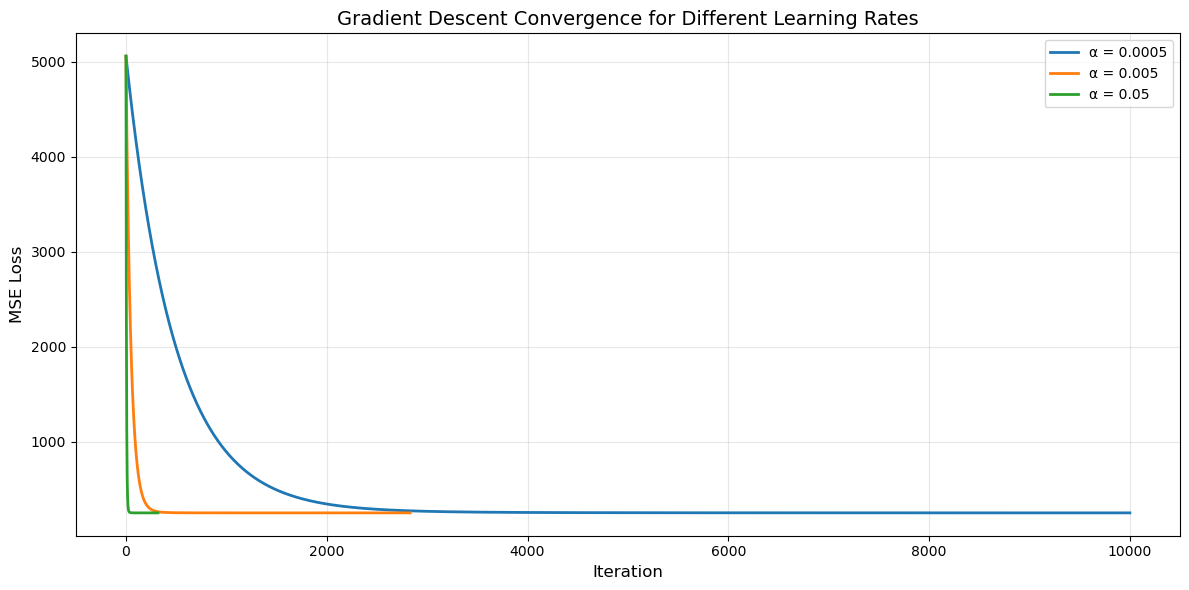

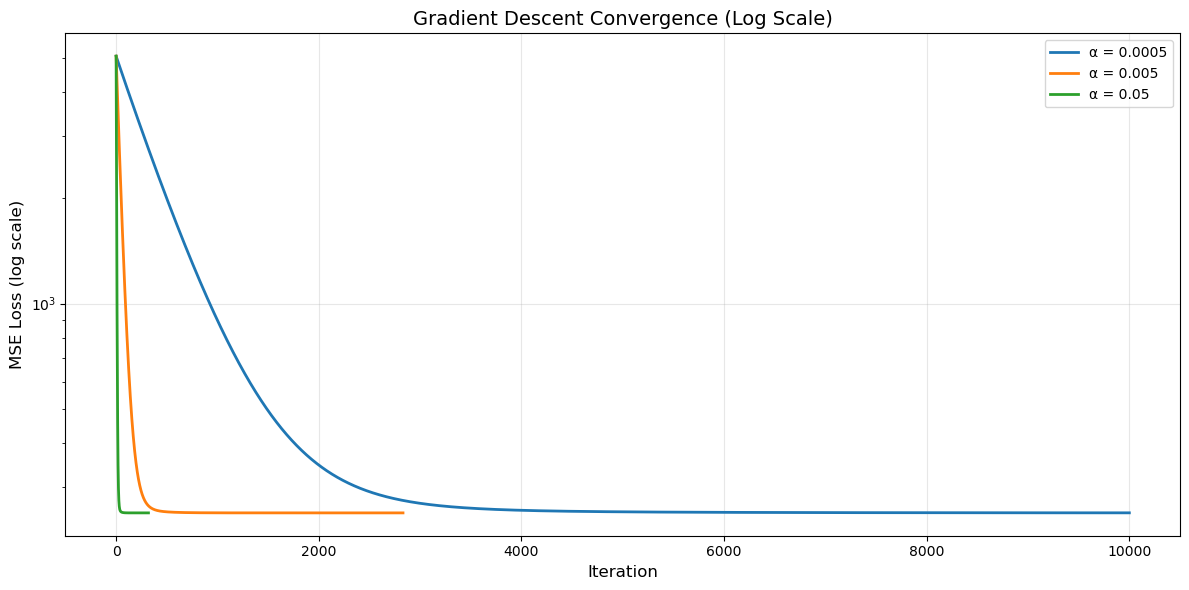

In [33]:
# Plot at least 3 learning rates
plot_alphas = [0.0005, 0.005, 0.05]  # Slow, medium, fast

plt.figure(figsize=(12, 6))

for alpha in plot_alphas:
    # Find the model for this alpha
    result = next((r for r in results if r['alpha'] == alpha), None)
    if result:
        model1 = result['model1']
        loss_history = model1.loss_history
        plt.plot(loss_history, label=f'α = {alpha}', linewidth=2)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Gradient Descent Convergence for Different Learning Rates', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Log scale plot to see details better
plt.figure(figsize=(12, 6))
for alpha in plot_alphas:
    result = next((r for r in results if r['alpha'] == alpha), None)
    if result:
        model1 = result['model1']
        loss_history = model1.loss_history
        plt.semilogy(loss_history, label=f'α = {alpha}', linewidth=2)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('MSE Loss (log scale)', fontsize=12)
plt.title('Gradient Descent Convergence (Log Scale)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 3E. Compare Methods
Compare the closed-form and gradient-descent weights/metrics. Briefly explain why they should be similar and why they may differ.

In [34]:
print("="*80)
print("3E. Comparison: Closed-Form vs Gradient Descent")
print("="*80)

# Get best GD model from your learning rate study
best_gd_model1 = None
best_alpha = None
best_dev_mse = float('inf')

for r in results:
    if r['status'] == 'Converged' and r['dev_mse'] < best_dev_mse:
        best_dev_mse = r['dev_mse']
        best_gd_model1 = r['model1']
        best_alpha = r['alpha']

print(f"\nBest GD Model: α = {best_alpha}")
print(f"GD Dev MSE: ${best_dev_mse:.2f}")

# Compute GD metrics
gd_train_mse = mse_loss(X_train_scaled_ones, y_train_scaled, best_gd_model1.weights)
gd_dev_mse = mse_loss(X_dev_scaled_ones, y_dev_scaled, best_gd_model1.weights)
gd_test_mse = mse_loss(X_test_scaled_ones, y_test_scaled, best_gd_model1.weights)

gd_train_mae = mae_loss(X_train_scaled_ones, y_train_scaled, best_gd_model1.weights)
gd_dev_mae = mae_loss(X_dev_scaled_ones, y_dev_scaled, best_gd_model1.weights)
gd_test_mae = mae_loss(X_test_scaled_ones, y_test_scaled, best_gd_model1.weights)

gd_train_r2 = r_squared(X_train_scaled_ones, y_train_scaled, best_gd_model1.weights)
gd_dev_r2 = r_squared(X_dev_scaled_ones, y_dev_scaled, best_gd_model1.weights)
gd_test_r2 = r_squared(X_test_scaled_ones, y_test_scaled, best_gd_model1.weights)

print("\n" + "="*80)
print("Metrics Comparison")
print("="*80)

print("\n" + "-"*80)
print(f"{'Metric':<12} {'Method':<20} {'Train':>15} {'Dev':>15} {'Test':>15}")
print("-"*80)

# MSE
print(f"{'MSE':<12} {'Closed-Form':<20} ${84.55:>14,.2f} ${65.26:>14,.2f} ${71.33:>14,.2f}")
print(f"{'MSE':<12} {'Gradient Descent':<20} ${float(gd_train_mse):>14,.2f} ${float(gd_dev_mse):>14,.2f} ${float(gd_test_mse):>14,.2f}")

# MAE
print(f"{'MAE':<12} {'Closed-Form':<20} ${3.50:>14,.2f} ${3.89:>14,.2f} ${4.07:>14,.2f}")
print(f"{'MAE':<12} {'Gradient Descent':<20} ${float(gd_train_mae):>14,.2f} ${float(gd_dev_mae):>14,.2f} ${float(gd_test_mae):>14,.2f}")

# R²
print(f"{'R²':<12} {'Closed-Form':<20} {0.94:>15.4f} {0.96:>15.4f} {0.96:>15.4f}")
print(f"{'R²':<12} {'Gradient Descent':<20} {float(gd_train_r2):>15.4f} {float(gd_dev_r2):>15.4f} {float(gd_test_r2):>15.4f}")

print("-"*80)

# Weight comparison
print("\n" + "="*80)
print("Weight Comparison")
print("="*80)

closed_form_weights = np.array([67.4549, -5.1818, -5.3419, 0.2911]).reshape(-1, 1)
gd_weights = best_gd_model1.weights

print(f"{'Weight':<25} {'Closed-Form':>15} {'Gradient Descent':>18} {'Difference':>12}")
print("-"*80)

feature_names = ['Bias', 'Population Density', "Avg Teacher's Salary", 'Median Household Income']
for name, cf_w, gd_w in zip(feature_names, closed_form_weights.flatten(), gd_weights.flatten()):
    diff = abs(cf_w - gd_w)
    print(f"{name:<25} {cf_w:>15.4f} {gd_w:>18.6f} {diff:>12.8f}")

print("="*80)

3E. Comparison: Closed-Form vs Gradient Descent

Best GD Model: α = 0.005
GD Dev MSE: $65.26

Metrics Comparison

--------------------------------------------------------------------------------
Metric       Method                         Train             Dev            Test
--------------------------------------------------------------------------------
MSE          Closed-Form          $         84.55 $         65.26 $         71.33
MSE          Gradient Descent     $         84.55 $         65.26 $         71.32
MAE          Closed-Form          $          3.50 $          3.89 $          4.07
MAE          Gradient Descent     $          3.50 $          3.89 $          4.07
R²           Closed-Form                   0.9400          0.9600          0.9600
R²           Gradient Descent              0.9362          0.9551          0.9591
--------------------------------------------------------------------------------

Weight Comparison
Weight                        Closed-Form   Gradie

##### Why They Should Be Similar:
Both closed-form and gradient descent optimize the same mean squared error loss function, which is convex. Therefore, they should converge to the same global minimum. The closed-form solution computes the exact minimum analytically via $w = (X^TX)^{-1}X^Ty$ , while gradient descent iteratively approaches this minimum."

##### Why They May Differ:
1) Gradient descent stops when the loss change falls below tolerance (1e-8), never reaching the exact minimum
2) Numerical precision differences between matrix inversion and iterative updates
3) Learning rate and max iterations may affect convergence
4) Initialization of weights in GD

### Problem 4 — Binary Classification, Activations, and Cross-Entropy [10 pts]

Use the Wisconsin Breast Cancer dataset. Implement logistic regression from scratch with $z_i=x_i^Tw$, $\hat{y}_i=\sigma(z_i)=1/(1+e^{-z_i})$, and binary cross-entropy loss.

#### 4A. Activations
Implement and plot sigmoid, tanh, and ReLU on $[-8,8]$, and explain why sigmoid fits binary classification.

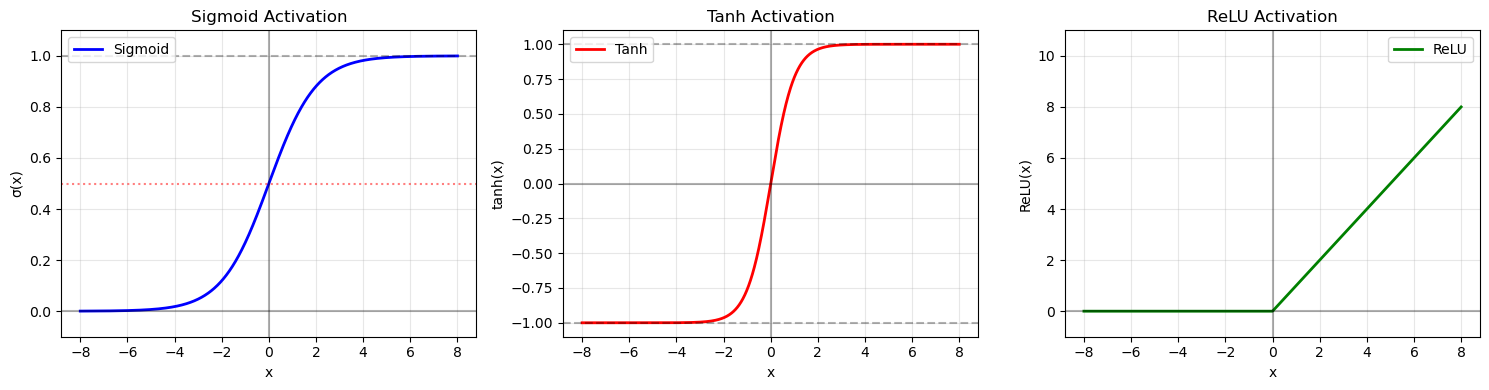

Sigmoid fits binary classification because the codomain is 0 to 1. It is better than a step because it is smooth (infinitely differentiable).


In [35]:
# Define activation functions
def sigmoid(x):
    """Sigmoid activation function: σ(x) = 1 / (1 + e^(-x))"""
    return 1 / (1 + np.exp(-x))

def tanh(x):
    """Hyperbolic tangent: tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))"""
    return np.tanh(x)

def relu(x):
    """ReLU (Rectified Linear Unit): max(0, x)"""
    return np.maximum(0, x)

# Generate x values from -8 to 8
x = np.linspace(-8, 8, 1000)

# Compute activation values
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

# Plot all three activation functions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sigmoid plot
axes[0].plot(x, y_sigmoid, 'b-', linewidth=2, label='Sigmoid')
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0].axhline(y=1, color='k', linestyle='--', alpha=0.3)
axes[0].axhline(y=0.5, color='r', linestyle=':', alpha=0.5)
axes[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('σ(x)')
axes[0].set_title('Sigmoid Activation')
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Tanh plot
axes[1].plot(x, y_tanh, 'r-', linewidth=2, label='Tanh')
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].axhline(y=1, color='k', linestyle='--', alpha=0.3)
axes[1].axhline(y=-1, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('tanh(x)')
axes[1].set_title('Tanh Activation')
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# ReLU plot
axes[2].plot(x, y_relu, 'g-', linewidth=2, label='ReLU')
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[2].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[2].set_xlabel('x')
axes[2].set_ylabel('ReLU(x)')
axes[2].set_title('ReLU Activation')
axes[2].set_ylim(-1, 11)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("Sigmoid fits binary classification because the codomain is 0 to 1. It is better than a step because it is smooth (infinitely differentiable).")

#### 4B. BCE Gradient
Derive the binary cross-entropy gradient and implement the sigmoid, loss, and gradient.


In [36]:
def binary_cross_entropy(y_true, y_pred):
    """
    BCE Loss: Measures prediction error for binary classification.
    
    y_true: actual labels (0 or 1)
    y_pred: predicted probabilities (from sigmoid)
    """
    # Add small epsilon to avoid log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    # BCE formula: -[y*log(p) + (1-y)*log(1-p)]
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

def bce_gradient(X, y, w):
    """
    Gradient of BCE loss with respect to weights.
    
    Conceptual meaning: 
    ∇L = (1/n) * X^T (σ(Xw) - y)
    
    Where:
    - σ(Xw) = predicted probabilities
    - y = actual labels (0 or 1)
    - (σ - y) = prediction error (positive if overpredicting, negative if underpredicting)
    """
    n = X.shape[0]
    
    # Forward pass: compute predictions
    z = X @ w           # Linear combination
    y_pred = sigmoid(z)  # Probabilities
    
    # Gradient: (1/n) * X^T (y_pred - y)
    gradient = (1/n) * X.T @ (y_pred - y)
    
    return gradient

# Simple test
print("="*60)
print("BCE Gradient Conceptual Example")
print("="*60)

# Example data
X_test = np.array([[1, 2],    # sample 1
                   [2, 1]])   # sample 2
y_test = np.array([[1],       # sample 1 is class 1
                   [0]])      # sample 2 is class 0
w_test = np.array([[0.5],
                   [-0.3]])

# Compute predictions
z = X_test @ w_test
y_pred = sigmoid(z)

print(f"\nPredictions (probabilities):")
print(f"  Sample 1: {y_pred[0,0]:.4f} (should be close to 1)")
print(f"  Sample 2: {y_pred[1,0]:.4f} (should be close to 0)")

# Compute loss
loss = binary_cross_entropy(y_test, y_pred)
print(f"\nBCE Loss: {loss:.4f} (lower is better)")

# Compute gradient
grad = bce_gradient(X_test, y_test, w_test)
print(f"\nGradient:\n{grad}")

BCE Gradient Conceptual Example

Predictions (probabilities):
  Sample 1: 0.4750 (should be close to 1)
  Sample 2: 0.6682 (should be close to 0)

BCE Loss: 0.9238 (lower is better)

Gradient:
[[ 0.40569818]
 [-0.1908853 ]]


#### 4C. Logistic Regression Class
Create a logistic regression model trained by gradient descent using the `sklearn` class structure: initializer, `fit`, `predict_proba`, `predict`, and `score`. Store the loss history.

In [37]:
class LogisticRegressionGD:
    def __init__(self, alpha=0.01, max_iterations=10000, tolerance=1e-8, threshold=0.5):
        """
        Logistic Regression trained by Gradient Descent.
        
        Parameters:
        alpha: learning rate (step size)
        max_iterations: maximum number of GD iterations
        tolerance: stop if loss change < tolerance
        threshold: decision boundary for classification (default 0.5)
        """
        self.alpha = alpha
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.threshold = threshold
        self.weights = None
        self.loss_history = []
    
    def _sigmoid(self, z):
        """Sigmoid activation function."""
        # Clip to avoid overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _binary_cross_entropy(self, X, y):
        """Compute BCE loss."""
        n = X.shape[0]
        y_pred = self._sigmoid(X @ self.weights)
        
        # Add small epsilon to avoid log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return loss
    
    def _gradient(self, X, y):
        """Compute BCE gradient: (1/n) X^T (σ(Xw) - y)"""
        n = X.shape[0]
        y_pred = self._sigmoid(X @ self.weights)
        gradient = (1/n) * X.T @ (y_pred - y)
        return gradient
    
    def fit(self, X, y):
        """
        Learn weights by gradient descent.
        
        Parameters:
        X: feature matrix (n_samples, n_features) - should already include bias column
        y: target vector (n_samples, 1) - binary labels (0 or 1)
        """
        # Ensure y is column vector
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        # Initialize weights to zeros
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        
        # Gradient descent loop
        for i in range(self.max_iterations):
            # Compute gradient
            grad = self._gradient(X, y)
            
            # Update weights: w = w - α * ∇L
            self.weights = self.weights - self.alpha * grad
            
            # Compute and store loss
            loss = self._binary_cross_entropy(X, y)
            self.loss_history.append(loss)
            
            # Check convergence
            if i > 0:
                loss_change = abs(self.loss_history[-2] - loss)
                if loss_change < self.tolerance:
                    print(f"Converged after {i+1} iterations")
                    break
        
        print(f"Final loss: {self.loss_history[-1]:.6f}")
        return self
    
    def predict_proba(self, X):
        """
        Return probabilities for class 1.
        
        Returns: array of shape (n_samples, 1) with probabilities in [0, 1]
        """
        if self.weights is None:
            raise ValueError("Must call fit() before predict_proba()")
        
        probabilities = self._sigmoid(X @ self.weights)
        return probabilities
    
    def predict(self, X):
        """
        Threshold probabilities to return class labels.
        
        Returns: array of shape (n_samples, 1) with values 0 or 1
        """
        probabilities = self.predict_proba(X)
        labels = (probabilities >= self.threshold).astype(int)
        return labels
    
    def score(self, X, y):
        """
        Return classification accuracy.
        
        Returns: float accuracy in [0, 1]
        """
        y_pred = self.predict(X)
        
        # Ensure y is column vector
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        accuracy = np.mean(y_pred == y)
        return accuracy
    
    def get_loss_history(self):
        """Return loss history for plotting."""
        return self.loss_history
    
    def get_weights(self):
        """Return learned weights."""
        return self.weights

#### 4D. Experiments
Split and standardize the data using training statistics only. Run at least eight experiments varying learning rate, iterations, or threshold. Report a results table, final test accuracy, confusion matrix, and a brief note on the most concerning error type.

In [38]:
from sklearn.datasets import load_breast_cancer

### load, split, Standardize and append ones the data

print("="*60)
print("Loading Wisconsin Breast Cancer Dataset")
print("="*60)

# Load the dataset
cancer = load_breast_cancer()

# Get feature and target data
X_raw = cancer.data      # Shape: (569, 30)
y_raw = cancer.target.reshape(-1, 1)    # Shape: (569,1)

# Print data
print(f"Dataset shape: {X_raw.shape}")
print(f"Features: {cancer.feature_names}")
print(f"Target classes: {cancer.target_names}")  # ['malignant' 'benign']
print(f"Class distribution:")
print(f"  Malignant (0): {np.sum(y_raw == 0)} samples")
print(f"  Benign (1):    {np.sum(y_raw == 1)} samples")

# Split the data
X_train, y_train, X_dev, y_dev, X_test, y_test = train_dev_test_split(
    X_raw, y_raw, train_ratio=0.6, dev_ratio=0.2, test_ratio=0.2, random_seed=42
)

# Create and fit the scaler on training data ONLY
scaler = StandardScaler()

# Using the train/dev/test split from 1C:
# Fit on TRAINING data only!
X_train_scaled = scaler.fit_transform(X_train)

# Transform dev and test using the SAME scaler
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# Reshape
y_train = y_train.reshape(-1, 1)
y_dev = y_dev.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Append ones (add bias column) AFTER standardization
X_train_scaled_ones = append_ones(X_train_scaled)
X_dev_scaled_ones = append_ones(X_dev_scaled)
X_test_scaled_ones = append_ones(X_test_scaled)

print(f"\nSplit sizes:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Dev:   {X_dev.shape[0]} samples")
print(f"  Test:  {X_test.shape[0]} samples")

print(f"\nFinal shapes with bias column:")
print(f"  X_train: {X_train_scaled_ones.shape}")
print(f"  X_dev:   {X_dev_scaled_ones.shape}")
print(f"  X_test:  {X_test_scaled_ones.shape}")

Loading Wisconsin Breast Cancer Dataset
Dataset shape: (569, 30)
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target classes: ['malignant' 'benign']
Class distribution:
  Malignant (0): 212 samples
  Benign (1):    357 samples

Split sizes:
  Train: 341 samples
  Dev:   113 samples
  Test:  115 samples

Final shapes with bias column:
  X_train: (341, 31)
  X_dev:   (113, 31)
  X_test:  (115, 31)


In [39]:
print("="*80)
print("4D. Learning Rate Study")
print("="*80)

# Define learning rates to test
learning_rates = [0.000001, 0.000005, 0.00001, 0.00005, 0.0001, 0.0005]

# Store results
results = []

print("\n" + "="*80)
print(f"{'α':<12} {'Iterations':<12} {'Final Train Loss':<20} {'Dev MSE':<15} {'Status':<15}")
print("-"*80)

# Test each learning rate
for alpha in learning_rates:
    # Create and train model
    model2 = LogisticRegressionGD(alpha=alpha, max_iterations=10000, tolerance=1e-8)
    model2.fit(X_train_scaled_ones, y_train)
    
    # Get training info
    iterations = len(model2.loss_history)
    final_loss = model2.loss_history[-1]
    
    # Compute dev MSE
    y_dev_pred = model2.predict(X_dev_scaled_ones)
    dev_mse = mse_loss(X_dev_scaled_ones, y_dev, model2.weights)
    
    # Convert to scalar if needed
    if hasattr(dev_mse, '__len__'):
        dev_mse = dev_mse[0, 0] if dev_mse.shape == (1, 1) else dev_mse[0]
    
    # Check convergence status
    if iterations < 10000:
        status = "Converged"
    else:
        status = "Max iter reached"
    
    # Check for divergence (loss exploding)
    if final_loss > 1e10 or np.isnan(final_loss):
        status = "Diverged"
        final_loss = np.nan
        dev_mse = np.nan
    
    # Store results
    results.append({
        'alpha': alpha,
        'iterations': iterations,
        'final_loss': final_loss,
        'dev_mse': dev_mse,
        'status': status,
        'model': model2
    })
    
    # Print row
    print(f"{alpha:<12.6f} {iterations:<12} {final_loss:<19,.2f} {dev_mse:<14,.2f} {status:<15}")

print("="*80)

# Create a summary table
print("\n" + "="*80)
print("Summary Table - Best Learning Rates")
print("="*80)
print(f"{'α (lr)':<12} {'Iterations':<12} {'Final Train Loss':<20} {'Dev MSE':<15} {'Status':<15}")
print("-"*80)

for r in results:
    if r['status'] != 'Diverged':
        print(f"{r['alpha']:<12.6f} {r['iterations']:<12} {r['final_loss']:<19,.2f} {r['dev_mse']:<14,.2f} {r['status']:<15}")

print("="*80)

# Find best model (lowest dev MSE)
best_result = min([r for r in results if r['status'] != 'Diverged' and not np.isnan(r['dev_mse'])], 
                   key=lambda x: x['dev_mse'])

print(f"\n✓ Best learning rate: α = {best_result['alpha']:.6f}")
print(f"  Dev MSE: {best_result['dev_mse']:,.2f}")
print(f"  Iterations: {best_result['iterations']}")
print(f"  Final train loss: {best_result['final_loss']:,.2f}")

4D. Learning Rate Study

α            Iterations   Final Train Loss     Dev MSE         Status         
--------------------------------------------------------------------------------
Final loss: 0.672924
0.000001     10000        0.67                0.59           Max iter reached
Final loss: 0.604138
0.000005     10000        0.60                0.48           Max iter reached
Final loss: 0.539177
0.000010     10000        0.54                0.43           Max iter reached
Final loss: 0.326907
0.000050     10000        0.33                1.03           Max iter reached
Final loss: 0.245062
0.000100     10000        0.25                2.25           Max iter reached
Final loss: 0.124234
0.000500     10000        0.12                9.92           Max iter reached

Summary Table - Best Learning Rates
α (lr)       Iterations   Final Train Loss     Dev MSE         Status         
--------------------------------------------------------------------------------
0.000001     10000      

Clearly the next step is to increase the max iterations using the identified optimal alpha 0.000010. First I will increase it to 50000 and if it still does not converge I will try 10000, but the computation time will start to limit us above this order of magnitude of iterations.

In [40]:
print("="*80)
print("4D. Max iteration Study 1")
print("="*80)

# Create and train model
model2 = LogisticRegressionGD(alpha=0.000010, max_iterations=50000, tolerance=1e-8)
model2.fit(X_train_scaled_ones, y_train)

# Compute predictions using the trained model
y_train_pred = model2.predict(X_train_scaled_ones)
y_dev_pred = model2.predict(X_dev_scaled_ones)
y_test_pred = model2.predict(X_test_scaled_ones)

# Get probabilities for ROC curve
y_train_proba = model2.predict_proba(X_train_scaled_ones)
y_dev_proba = model2.predict_proba(X_dev_scaled_ones)
y_test_proba = model2.predict_proba(X_test_scaled_ones)

# Calculate accuracies
train_acc = model2.score(X_train_scaled_ones, y_train)
dev_acc = model2.score(X_dev_scaled_ones, y_dev)
test_acc = model2.score(X_test_scaled_ones, y_test)

# Compute error metrics using the predictions
MSE_train = mse_loss(X_train_scaled_ones, y_train, model2.weights)
MSE_dev = mse_loss(X_dev_scaled_ones, y_dev, model2.weights)
MSE_test = mse_loss(X_test_scaled_ones, y_test, model2.weights)

MAE_train = mae_loss(X_train_scaled_ones, y_train, model2.weights)
MAE_dev = mae_loss(X_dev_scaled_ones, y_dev, model2.weights)
MAE_test = mae_loss(X_test_scaled_ones, y_test, model2.weights)

R2_train = r_squared(X_train_scaled_ones, y_train, model2.weights)
R2_dev = r_squared(X_dev_scaled_ones, y_dev, model2.weights)
R2_test = r_squared(X_test_scaled_ones, y_test, model2.weights)
print("Training complete.")

4D. Max iteration Study 1
Final loss: 0.326912
Training complete.


In [41]:
from sklearn.metrics import confusion_matrix, classification_report # Metrics

print("="*80)
print("4D. Logistic Regression Experiments - Breast Cancer Classification: Model metrics")
print("="*80)

# Model results
print("\n" + "="*80)
print("Model Training Results")
print("="*80)
print(f"Learning rate (α): 0.00001")
print(f"Max iterations: 15000")
print(f"Converged after: {len(model2.loss_history)} iterations")
print(f"Final training loss: {model2.loss_history[-1]:.6f}")

print("\n" + "="*80)
print("Results Table")
print("="*80)
print(f"{'Metric':<20} {'Train':>12} {'Dev':>12} {'Test':>12}")
print("-"*56)
print(f"{'Accuracy':<20} {train_acc:>11.4f} {dev_acc:>11.4f} {test_acc:>11.4f}")
print(f"{'MSE':<20} {MSE_train:>11.4f} {MSE_dev:>11.4f} {MSE_test:>11.4f}")
print(f"{'MAE':<20} {MAE_train:>11.4f} {MAE_dev:>11.4f} {MAE_test:>11.4f}")
print(f"{'R²':<20} {float(R2_train):>11.4f} {float(R2_dev):>11.4f} {float(R2_test):>11.4f}")
print("="*80)

# Confusion Matrix Analysis
print("\n" + "="*80)
print("Confusion Matrix Analysis (Test Set)")
print("="*80)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extract values
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Benign(0)  Malignant(1)")
print(f"Actual Benign(0)    {tn:3d}        {fp:3d}")
print(f"       Malignant(1)  {fn:3d}        {tp:3d}")
print()

# Calculate metrics
total = tn + fp + fn + tp
accuracy = (tp + tn) / total
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Performance Metrics:")
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}  (of predicted malignant, how many were actually malignant)")
print(f"  Recall:      {recall:.4f}  (of actual malignant, how many were caught)")
print(f"  Specificity: {specificity:.4f}  (of actual benign, how many correctly identified)")
print(f"  F1 Score:    {f1_score:.4f}")

# Error type analysis
print("\n" + "="*80)
print("Error Type Analysis - Clinical Impact")
print("="*80)

print(f"\nFalse Negatives (FN): {fn}")
print(f"  → Patient has CANCER but model predicted BENIGN")
print(f"  → SEVERE ERROR! Delayed treatment, potentially fatal.")
print(f"  → Cost: Very High (life-threatening)")

print(f"\nFalse Positives (FP): {fp}")
print(f"  → Patient is HEALTHY but model predicted CANCER")
print(f"  → Error leads to unnecessary stress, biopsies, treatment")
print(f"  → Cost: Moderate (anxiety, medical costs)")

print(f"\nError Ratio: FN:FP = {fn}:{fp}")
if fn > fp:
    print(f"  ⚠️  WARNING: More false negatives than false positives!")
    print(f"     Model is missing cancer cases - needs improvement!")
else:
    print(f"  ✓ Model has more false positives than false negatives")
    print(f"    This is safer for cancer screening (better to over-diagnose than miss cancer)")



4D. Logistic Regression Experiments - Breast Cancer Classification: Model metrics

Model Training Results
Learning rate (α): 0.00001
Max iterations: 15000
Converged after: 50000 iterations
Final training loss: 0.326912

Results Table
Metric                      Train          Dev         Test
--------------------------------------------------------
Accuracy                  0.9443      0.9381      0.9478
MSE                       1.5356      1.0300      1.7975
MAE                       0.8276      0.7511      0.8692
R²                       -5.6594     -3.4104     -6.4382

Confusion Matrix Analysis (Test Set)

Confusion Matrix:
                 Predicted
                 Benign(0)  Malignant(1)
Actual Benign(0)     43          4
       Malignant(1)    2         66

Performance Metrics:
  Accuracy:    0.9478
  Precision:   0.9429  (of predicted malignant, how many were actually malignant)
  Recall:      0.9706  (of actual malignant, how many were caught)
  Specificity: 0.9149  (of actua

In [42]:
print("="*80)
print("4D. Max iteration Study 2")
print("="*80)

# Create and train model
model2 = LogisticRegressionGD(alpha=0.000010, max_iterations=100000, tolerance=1e-8)
model2.fit(X_train_scaled_ones, y_train)

# Compute predictions using the trained model
y_train_pred = model2.predict(X_train_scaled_ones)
y_dev_pred = model2.predict(X_dev_scaled_ones)
y_test_pred = model2.predict(X_test_scaled_ones)

# Get probabilities for ROC curve
y_train_proba = model2.predict_proba(X_train_scaled_ones)
y_dev_proba = model2.predict_proba(X_dev_scaled_ones)
y_test_proba = model2.predict_proba(X_test_scaled_ones)

# Calculate accuracies
train_acc = model2.score(X_train_scaled_ones, y_train)
dev_acc = model2.score(X_dev_scaled_ones, y_dev)
test_acc = model2.score(X_test_scaled_ones, y_test)

# Compute error metrics using the predictions
MSE_train = mse_loss(X_train_scaled_ones, y_train, model2.weights)
MSE_dev = mse_loss(X_dev_scaled_ones, y_dev, model2.weights)
MSE_test = mse_loss(X_test_scaled_ones, y_test, model2.weights)

MAE_train = mae_loss(X_train_scaled_ones, y_train, model2.weights)
MAE_dev = mae_loss(X_dev_scaled_ones, y_dev, model2.weights)
MAE_test = mae_loss(X_test_scaled_ones, y_test, model2.weights)

R2_train = r_squared(X_train_scaled_ones, y_train, model2.weights)
R2_dev = r_squared(X_dev_scaled_ones, y_dev, model2.weights)
R2_test = r_squared(X_test_scaled_ones, y_test, model2.weights)
print("Training complete.")

4D. Max iteration Study 2
Final loss: 0.245068
Training complete.


In [43]:
from sklearn.metrics import confusion_matrix, classification_report # Metrics

print("="*80)
print("4D. Logistic Regression Experiments - Breast Cancer Classification: Model metrics")
print("="*80)

# Model results
print("\n" + "="*80)
print("Model Training Results")
print("="*80)
print(f"Learning rate (α): 0.00001")
print(f"Max iterations: 15000")
print(f"Converged after: {len(model2.loss_history)} iterations")
print(f"Final training loss: {model2.loss_history[-1]:.6f}")

print("\n" + "="*80)
print("Results Table")
print("="*80)
print(f"{'Metric':<20} {'Train':>12} {'Dev':>12} {'Test':>12}")
print("-"*56)
print(f"{'Accuracy':<20} {train_acc:>11.4f} {dev_acc:>11.4f} {test_acc:>11.4f}")
print(f"{'MSE':<20} {MSE_train:>11.4f} {MSE_dev:>11.4f} {MSE_test:>11.4f}")
print(f"{'MAE':<20} {MAE_train:>11.4f} {MAE_dev:>11.4f} {MAE_test:>11.4f}")
print(f"{'R²':<20} {float(R2_train):>11.4f} {float(R2_dev):>11.4f} {float(R2_test):>11.4f}")
print("="*80)

# Confusion Matrix Analysis
print("\n" + "="*80)
print("Confusion Matrix Analysis (Test Set)")
print("="*80)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Extract values
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Benign(0)  Malignant(1)")
print(f"Actual Benign(0)    {tn:3d}        {fp:3d}")
print(f"       Malignant(1)  {fn:3d}        {tp:3d}")
print()

# Calculate metrics
total = tn + fp + fn + tp
accuracy = (tp + tn) / total
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Performance Metrics:")
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}  (of predicted malignant, how many were actually malignant)")
print(f"  Recall:      {recall:.4f}  (of actual malignant, how many were caught)")
print(f"  Specificity: {specificity:.4f}  (of actual benign, how many correctly identified)")
print(f"  F1 Score:    {f1_score:.4f}")

# Error type analysis
print("\n" + "="*80)
print("Error Type Analysis - Clinical Impact")
print("="*80)

print(f"\nFalse Negatives (FN): {fn}")
print(f"  → Patient has CANCER but model predicted BENIGN")
print(f"  → SEVERE ERROR! Delayed treatment, potentially fatal.")
print(f"  → Cost: Very High (life-threatening)")

print(f"\nFalse Positives (FP): {fp}")
print(f"  → Patient is HEALTHY but model predicted CANCER")
print(f"  → Error leads to unnecessary stress, biopsies, treatment")
print(f"  → Cost: Moderate (anxiety, medical costs)")

print(f"\nError Ratio: FN:FP = {fn}:{fp}")
if fn > fp:
    print(f"  ⚠️  WARNING: More false negatives than false positives!")
    print(f"     Model is missing cancer cases - needs improvement!")
else:
    print(f"  ✓ Model has more false positives than false negatives")
    print(f"    This is safer for cancer screening (better to over-diagnose than miss cancer)")



4D. Logistic Regression Experiments - Breast Cancer Classification: Model metrics

Model Training Results
Learning rate (α): 0.00001
Max iterations: 15000
Converged after: 100000 iterations
Final training loss: 0.245068

Results Table
Metric                      Train          Dev         Test
--------------------------------------------------------
Accuracy                  0.9619      0.9469      0.9478
MSE                       3.3653      2.2450      3.9764
MAE                       1.2769      1.1431      1.3253
R²                      -13.5938     -8.6132    -15.4542

Confusion Matrix Analysis (Test Set)

Confusion Matrix:
                 Predicted
                 Benign(0)  Malignant(1)
Actual Benign(0)     43          4
       Malignant(1)    2         66

Performance Metrics:
  Accuracy:    0.9478
  Precision:   0.9429  (of predicted malignant, how many were actually malignant)
  Recall:      0.9706  (of actual malignant, how many were caught)
  Specificity: 0.9149  (of actu

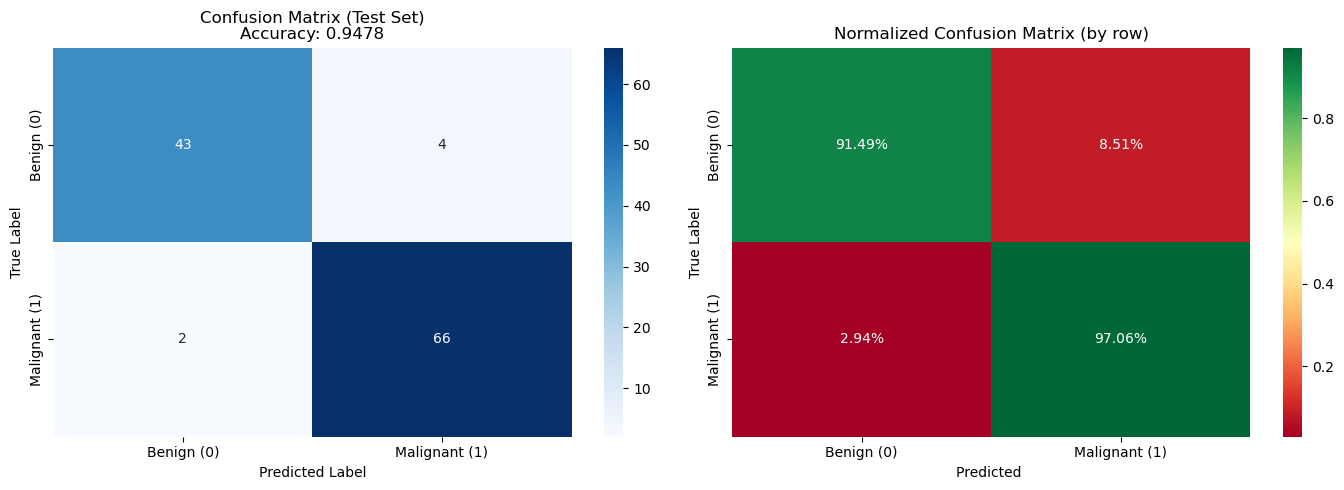


Clinical Impact Assessment

Missed Cancer Rate: 2.9% (2 out of 68 cancer patients missed)
  ✓ 

False Alarm Rate: 8.5% (4 out of 47 healthy patients flagged)
  ✓ Acceptable false positive rate.

Detailed Classification Report
               precision    recall  f1-score   support

   Benign (0)       0.96      0.91      0.93        47
Malignant (1)       0.94      0.97      0.96        68

     accuracy                           0.95       115
    macro avg       0.95      0.94      0.95       115
 weighted avg       0.95      0.95      0.95       115


Most Concerning Error Cases (False Negatives)

Found 2 false negatives:
  Sample 96: Predicted probability of cancer = 0.4751 (should be >0.5)
           → Model was fairly confident it was benign, but actually malignant!
  Sample 15: Predicted probability of cancer = 0.4305 (should be >0.5)
           → Model was fairly confident it was benign, but actually malignant!


In [44]:
import seaborn as sns # Visualization

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[0].set_title(f'Confusion Matrix (Test Set)\nAccuracy: {accuracy:.4f}', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')


# Plot 2: Normalized confusion matrix (percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[1].set_title('Normalized Confusion Matrix (by row)', fontsize=12)
axes[1].set_xlabel('Predicted ')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Error impact analysis
print("\n" + "="*80)
print("Clinical Impact Assessment")
print("="*80)

# Calculate risk scores
if fn > 0:
    missed_cancer_rate = fn / (tp + fn) * 100
    print(f"\nMissed Cancer Rate: {missed_cancer_rate:.1f}% ({fn} out of {tp+fn} cancer patients missed)")
    if missed_cancer_rate > 5:
        print(f"  ⚠️  HIGH RISK: Too many cancer cases missed!")
    else:
        print(f"  ✓ ")

if fp > 0:
    false_alarm_rate = fp / (tn + fp) * 100
    print(f"\nFalse Alarm Rate: {false_alarm_rate:.1f}% ({fp} out of {tn+fp} healthy patients flagged)")
    if false_alarm_rate > 10:
        print(f"  ⚠️  HIGH: Too many false positives (unnecessary biopsies)")
    else:
        print(f"  ✓ Acceptable false positive rate.")

# Classification Report
print("\n" + "="*80)
print("Detailed Classification Report")
print("="*80)
print(classification_report(y_test, y_test_pred, 
                            target_names=['Benign (0)', 'Malignant (1)']))

# Optional: Find the most concerning error cases
print("\n" + "="*80)
print("Most Concerning Error Cases (False Negatives)")
print("="*80)

# Get probabilities for test set
test_probs = model2.predict_proba(X_test_scaled_ones)
test_probs = test_probs.flatten()

# Find false negative indices (actual malignant, predicted benign)
fn_mask = (y_test.flatten() == 1) & (y_test_pred.flatten() == 0)
fn_indices = np.where(fn_mask)[0]
fn_probs = test_probs[fn_mask]

if len(fn_indices) > 0:
    print(f"\nFound {len(fn_indices)} false negatives:")
    # Sort by probability (highest confidence wrong predictions are most concerning)
    sorted_fn = sorted(zip(fn_indices, fn_probs), key=lambda x: x[1], reverse=True)
    for idx, prob in sorted_fn[:5]:  # Show top 5 most concerning
        print(f"  Sample {idx}: Predicted probability of cancer = {prob:.4f} (should be >0.5)")
        print(f"           → Model was fairly confident it was benign, but actually malignant!")
else:
    print("\n  ✓ No false negatives! Perfect recall on test set.")

# ROC Curve (optional)


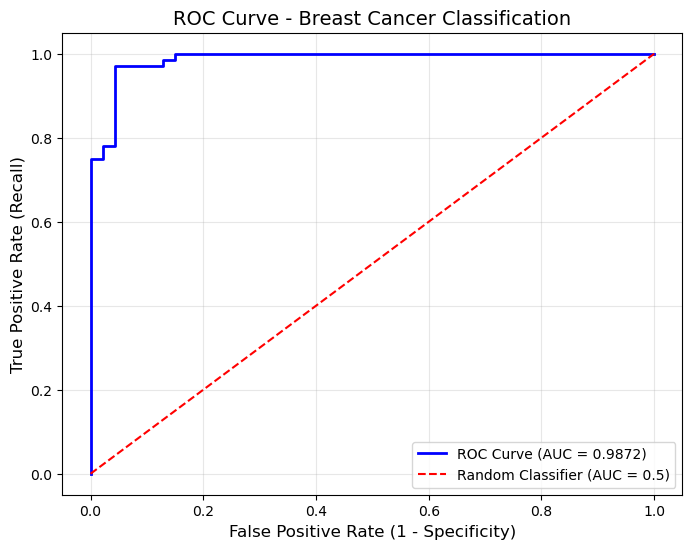


AUC Score: 0.9872
  AUC > 0.9: Excellent classifier
  AUC 0.8-0.9: Good classifier
  AUC < 0.8: Needs improvement


In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Breast Cancer Classification', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nAUC Score: {auc:.4f}")
print(f"  AUC > 0.9: Excellent classifier")
print(f"  AUC 0.8-0.9: Good classifier")
print(f"  AUC < 0.8: Needs improvement")

Although the overall performance is pretty good we could shift the threshold to reduce the number of false negative

### Problem 5 — Drawing, Deriving, and Implementing a Multiclass Classifier [10 pts]

Generalize binary logistic regression to multiclass classification using `load_digits()`.

#### 5A. Draw the Model
For $d=4$ features and $K=3$ classes, draw the model with input nodes, class logit nodes, directed weights, the weight matrix shape, softmax, and probability vector shape.

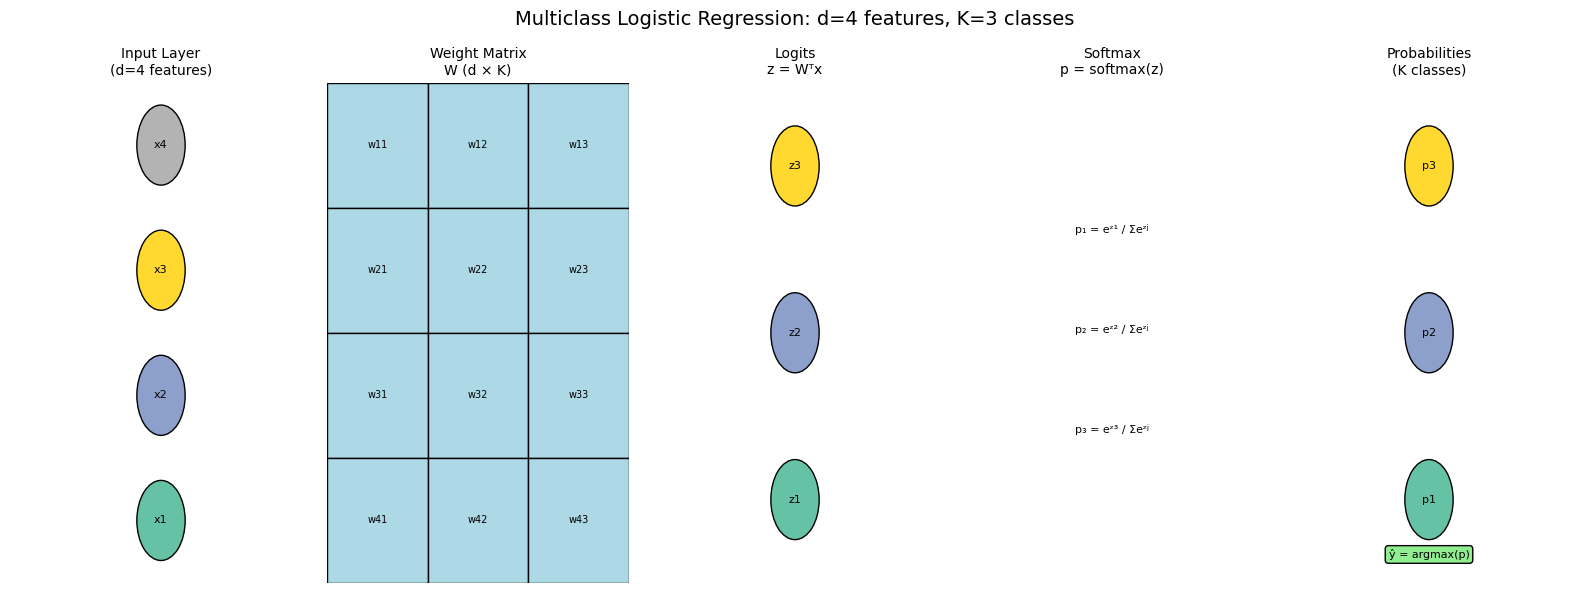

In [46]:
def draw_multiclass_model():
    fig, axes = plt.subplots(1, 5, figsize=(16, 6))
    
    # Data for nodes
    d = 4  # features
    K = 3  # classes
    
    # Positions
    x_pos = [0, 1, 2, 3]
    hidden_pos = [0, 1, 2]
    
    # Colors
    colors = plt.cm.Set2(np.linspace(0, 1, max(d, K)))
    
    # 1. Input Layer
    ax = axes[0]
    ax.set_title('Input Layer\n(d=4 features)', fontsize=10)
    for i in range(d):
        circle = plt.Circle((0.5, (i+0.5)/d), 0.08, color=colors[i], ec='black')
        ax.add_patch(circle)
        ax.text(0.5, (i+0.5)/d, f'x{i+1}', ha='center', va='center', fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # 2. Weight arrows (conceptual)
    ax = axes[1]
    ax.set_title('Weight Matrix\nW (d × K)', fontsize=10)
    # Draw matrix as grid
    for i in range(d):
        for j in range(K):
            rect = plt.Rectangle((j/K, 1-(i+1)/d), 1/K, 1/d, 
                                  facecolor='lightblue', edgecolor='black')
            ax.add_patch(rect)
            ax.text(j/K + 0.5/K, 1-(i+0.5)/d, f'w{i+1}{j+1}', 
                    ha='center', va='center', fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # 3. Logits Layer
    ax = axes[2]
    ax.set_title('Logits\nz = Wᵀx', fontsize=10)
    for j in range(K):
        circle = plt.Circle((0.5, (j+0.5)/K), 0.08, color=colors[j], ec='black')
        ax.add_patch(circle)
        ax.text(0.5, (j+0.5)/K, f'z{j+1}', ha='center', va='center', fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # 4. Softmax
    ax = axes[3]
    ax.set_title('Softmax\np = softmax(z)', fontsize=10)
    ax.text(0.5, 0.7, 'p₁ = eᶻ¹ / Σeᶻʲ', ha='center', fontsize=8)
    ax.text(0.5, 0.5, 'p₂ = eᶻ² / Σeᶻʲ', ha='center', fontsize=8)
    ax.text(0.5, 0.3, 'p₃ = eᶻ³ / Σeᶻʲ', ha='center', fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # 5. Probability Output
    ax = axes[4]
    ax.set_title('Probabilities\n(K classes)', fontsize=10)
    for j in range(K):
        circle = plt.Circle((0.5, (j+0.5)/K), 0.08, color=colors[j], ec='black')
        ax.add_patch(circle)
        ax.text(0.5, (j+0.5)/K, f'p{j+1}', ha='center', va='center', fontsize=8)
    # Add argmax text
    ax.text(0.5, 0.05, 'ŷ = argmax(p)', ha='center', fontsize=8, 
            bbox=dict(boxstyle="round", facecolor='lightgreen'))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    plt.suptitle(f'Multiclass Logistic Regression: d={d} features, K={K} classes', fontsize=14)
    plt.tight_layout()
    plt.show()

# Draw the model
draw_multiclass_model()

#### 5B. Define the Model
For general $n$, $d$, and $K$, define the design matrix $X$ with a column of ones, one-hot labels $Y$, weight matrix $W$, logits $Z$, and probabilities $P$, including dimensions. Write equations for $Z$ and $P$.

1) The design matrix X is the matrix of shape (n, d+1) that contains the raw data - the features and instances you are working with.
2) The one hot labels Y are the (n, K) objects that describe our data - it is what we are trying to predict.
3) The weight matrix W is the (d+1, K) matrix that learns to encode the patterns the model uses to predict.
4) Logits Z are (n, K) raw scores to be turned into predictions (probabilities) by normalization - they are computed with:	Z = XW.
5) Probabilities P are the normalized Logits and represent the confidence of the predictions the model makes - P = softmax(Z).

#### 5C. Write the Loss
Write the average multiclass cross-entropy loss using $Y$ and $P$. If you add L2 regularization, state whether the bias row of $W$ is regularized.

$L(W) = -\frac{1}{n}  Σ_{i=1}^{n} Σ_{j=1}^{K} Y_{ij} log(P_{ij})$ 
\
\
If you add $L_2$ parameterization you do not regularize the bias row of W

#### 5D. Derive the Gradient
Derive the gradient with respect to $W$, including the shape of the gradient, a vectorized formula for $dW$, and the L2 term if used.

without $L_2$ regularization:
$dW = \frac{1}{n}X^T(P-Y)$ 
\
\
with $L_2$ regularization:
$dW = \frac{1}{n}X^T(P-Y) + \lambda W_0$ , where $W_0$ is the weight matrix with the bias column set to 0 
\
\
the gradient is of shape (d+1, K)


#### 5E. Softmax Regression Class
Implement a softmax regression model trained by gradient descent using the `sklearn` class structure: initializer, `fit`, `predict_proba`, `predict`, and `score`. Use stable softmax, one-hot labels, full-batch gradient descent, loss history, and optional L2 without bias regularization.

In [47]:
class SoftmaxRegressionGD:
    def __init__(self, alpha=0.1, lambda_=0.0, max_iterations=5000, tolerance=1e-8):
        """
        Softmax Regression (Multiclass Logistic Regression) trained by Gradient Descent.
        
        Parameters:
        alpha: learning rate (step size)
        lambda_: L2 regularization strength (0 = no regularization)
        max_iterations: maximum number of GD iterations
        tolerance: stop if loss change < tolerance
        """
        self.alpha = alpha
        self.lambda_ = lambda_
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.W = None  # Weight matrix (d+1, K)
        self.loss_history = []
        self.classes_ = None
    
    def _softmax(self, Z):
        """
        Stable softmax to avoid numerical overflow.
        
        Parameters:
        Z: logits, shape (n, K)
        
        Returns:
        P: probabilities, shape (n, K)
        """
        # Subtract max for numerical stability
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shifted)
        P = exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
        return P
    
    def _one_hot(self, y, K):
        """
        Convert integer labels to one-hot encoding.
        
        Parameters:
        y: labels, shape (n, 1) or (n,)
        K: number of classes
        
        Returns:
        Y: one-hot matrix, shape (n, K)
        """
        n = len(y)
        Y = np.zeros((n, K))
        Y[np.arange(n), y.flatten().astype(int)] = 1
        return Y
    
    def _cross_entropy_loss(self, X, Y, P):
        """
        Compute cross-entropy loss with optional L2 regularization.
        Regularization excludes bias row (first row of W).
        """
        n = X.shape[0]
        # Cross-entropy loss
        epsilon = 1e-15
        P = np.clip(P, epsilon, 1 - epsilon)
        ce_loss = -1/n * np.sum(Y * np.log(P))
        
        # L2 regularization (exclude bias row)
        if self.lambda_ > 0:
            # Exclude first row (bias) from regularization
            W_no_bias = self.W[1:, :]
            l2_penalty = (self.lambda_ / (2 * n)) * np.sum(W_no_bias ** 2)
            return ce_loss + l2_penalty
        else:
            return ce_loss
    
    def _gradient(self, X, Y, P):
        """
        Compute gradient of loss with respect to W.
        
        Gradient: dW = (1/n) X^T (P - Y) + lambda * W_tilde
        where W_tilde has bias row set to zero for regularization.
        """
        n = X.shape[0]
        # Gradient from cross-entropy
        dW = (1/n) * X.T @ (P - Y)
        
        # Add L2 regularization gradient (exclude bias row)
        if self.lambda_ > 0:
            W_reg = np.zeros_like(self.W)
            W_reg[1:, :] = (self.lambda_ / n) * self.W[1:, :]
            dW += W_reg
        
        return dW
    
    def fit(self, X, y):
        """
        Learn weight matrix by gradient descent.
        
        Parameters:
        X: feature matrix (n, d+1) - should already include bias column!
        y: target vector (n, 1) or (n,) - integer class labels (0, 1, ..., K-1)
        
        Returns:
        self
        """
        # Ensure X is 2D
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        # Convert y to 1D integer array
        y = y.flatten().astype(int)
        
        # Get dimensions
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        
        # Convert y to one-hot
        Y = self._one_hot(y, K)
        
        # Initialize weight matrix to zeros
        self.W = np.zeros((n_features, K))
        
        # Gradient descent loop
        for iteration in range(self.max_iterations):
            # Forward pass
            Z = X @ self.W
            P = self._softmax(Z)
            
            # Compute loss
            loss = self._cross_entropy_loss(X, Y, P)
            self.loss_history.append(loss)
            
            # Compute gradient
            dW = self._gradient(X, Y, P)
            
            # Update weights
            self.W -= self.alpha * dW
            
            # Check convergence
            if iteration > 0:
                loss_change = abs(self.loss_history[-2] - self.loss_history[-1])
                if loss_change < self.tolerance:
                    print(f"Converged after {iteration + 1} iterations")
                    break
        
        print(f"Final loss: {self.loss_history[-1]:.6f}")
        return self
    
    def predict_proba(self, X):
        """
        Return class probabilities for each sample.
        
        Parameters:
        X: feature matrix (n, d+1) - must include bias column
        
        Returns:
        probabilities: shape (n, K) where each row sums to 1
        """
        if self.W is None:
            raise ValueError("Must call fit() before predict_proba()")
        
        Z = X @ self.W
        P = self._softmax(Z)
        return P
    
    def predict(self, X):
        """
        Return predicted class labels.
        
        Parameters:
        X: feature matrix (n, d+1) - must include bias column
        
        Returns:
        labels: shape (n,) with integer class labels
        """
        probabilities = self.predict_proba(X)
        labels = np.argmax(probabilities, axis=1)
        return labels
    
    def score(self, X, y):
        """
        Return classification accuracy.
        
        Parameters:
        X: feature matrix (n, d+1) - must include bias column
        y: true labels (n, 1) or (n,)
        
        Returns:
        accuracy: float in [0, 1]
        """
        y_pred = self.predict(X)
        y_true = y.flatten()
        accuracy = np.mean(y_pred == y_true)
        return accuracy
    
    def get_loss_history(self):
        """Return loss history for plotting."""
        return self.loss_history
    
    def get_weights(self):
        """Return learned weight matrix."""
        return self.W

#### 5F. Experiments
Split, standardize, and run at least 12 experiments over learning rate, L2 penalty, and iterations. Report dev results, final test accuracy, confusion matrix, and common digit confusions.

In [48]:
from sklearn.datasets import load_digits

### load, split, Standardize and append ones the data

print("="*60)
print("Load Handwritten Digits Dataset")
print("="*60)

# Load the dataset
digits = load_digits()

# Get feature and target data
X_raw = digits.data      # Shape: (1797, 64)
y_raw = digits.target.reshape(-1, 1)    # Shape: (1797, 1)

# Print data
print(f"Dataset shape: {X_raw.shape}")

# Split the data
X_train, y_train, X_dev, y_dev, X_test, y_test = train_dev_test_split(
    X_raw, y_raw, train_ratio=0.6, dev_ratio=0.2, test_ratio=0.2, random_seed=42
)

# Create and fit the scaler on training data ONLY
scaler = StandardScaler()

# Using the train/dev/test split from 1C:
# Fit on TRAINING data only!
X_train_scaled = scaler.fit_transform(X_train)

# Transform dev and test using the SAME scaler
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# Reshape
y_train= y_train.reshape(-1, 1)
y_dev = y_dev.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Append ones (add bias column) AFTER standardization
X_train_scaled_ones = append_ones(X_train_scaled)
X_dev_scaled_ones = append_ones(X_dev_scaled)
X_test_scaled_ones = append_ones(X_test_scaled)

print(f"\nSplit sizes:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Dev:   {X_dev.shape[0]} samples")
print(f"  Test:  {X_test.shape[0]} samples")

print(f"\nFinal shapes with bias column:")
print(f"  X_train: {X_train_scaled_ones.shape}")
print(f"  X_dev:   {X_dev_scaled_ones.shape}")
print(f"  X_test:  {X_test_scaled_ones.shape}")


Load Handwritten Digits Dataset
Dataset shape: (1797, 64)

Split sizes:
  Train: 1078 samples
  Dev:   359 samples
  Test:  360 samples

Final shapes with bias column:
  X_train: (1078, 65)
  X_dev:   (359, 65)
  X_test:  (360, 65)


In [50]:
print("="*80)
print("5F. Multiclass Classifiers - Handwritten Digits Dataset: Model metrics")
print("="*80)

# Create and train model
model3 = SoftmaxRegressionGD(alpha=0.01,lambda_=0.0, max_iterations=1000, tolerance=1e-8,)
model3.fit(X_train_scaled_ones, y_train)

# Compute predictions using the trained model
y_train_pred = model3.predict(X_train_scaled_ones)
y_dev_pred = model3.predict(X_dev_scaled_ones)
y_test_pred = model3.predict(X_test_scaled_ones)

# Get probabilities for ROC curve
y_train_proba = model3.predict_proba(X_train_scaled_ones)
y_dev_proba = model3.predict_proba(X_dev_scaled_ones)
y_test_proba = model3.predict_proba(X_test_scaled_ones)

# Calculate accuracies
train_acc = model3.score(X_train_scaled_ones, y_train)
dev_acc = model3.score(X_dev_scaled_ones, y_dev)
test_acc = model3.score(X_test_scaled_ones, y_test)

# Compute error metrics using the predictions
MSE_train = mse_loss(X_train_scaled_ones, y_train, model3.W)
MSE_dev = mse_loss(X_dev_scaled_ones, y_dev, model3.W)
MSE_test = mse_loss(X_test_scaled_ones, y_test, model3.W)

MAE_train = mae_loss(X_train_scaled_ones, y_train, model3.W)
MAE_dev = mae_loss(X_dev_scaled_ones, y_dev, model3.W)
MAE_test = mae_loss(X_test_scaled_ones, y_test, model3.W)

R2_train = r_squared(X_train_scaled_ones, y_train, model3.W)
R2_dev = r_squared(X_dev_scaled_ones, y_dev, model3.W)
R2_test = r_squared(X_test_scaled_ones, y_test, model3.W)
print("Training complete.")

print("="*80)

# Model results
print("Model Training Results")
print("="*80)
print(f"Learning rate (α): 0.01")
print(f"Lambda: 0")
print(f"Max iterations: 1000")
print(f"Converged after: {len(model3.loss_history)} iterations")
print(f"Final training loss: {model3.loss_history[-1]:.6f}")

print("\n" + "="*80)
print("Results Table")
print("="*80)
print(f"{'Metric':<20} {'Train':>12} {'Dev':>12} {'Test':>12}")
print("-"*56)
print(f"{'Accuracy':<20} {train_acc:>11.4f} {dev_acc:>11.4f} {test_acc:>11.4f}")
print(f"{'MSE':<20} {MSE_train:>11.4f} {MSE_dev:>11.4f} {MSE_test:>11.4f}")
print(f"{'MAE':<20} {MAE_train:>11.4f} {MAE_dev:>11.4f} {MAE_test:>11.4f}")
print(f"{'R²':<20} {float(R2_train):>11.4f} {float(R2_dev):>11.4f} {float(R2_test):>11.4f}")
print("="*80)

5F. Multiclass Classifiers - Handwritten Digits Dataset: Model metrics
Final loss: 0.284285
Training complete.
Model Training Results
Learning rate (α): 0.01
Lambda: 0
Max iterations: 1000
Converged after: 1000 iterations
Final training loss: 0.284285

Results Table
Metric                      Train          Dev         Test
--------------------------------------------------------
Accuracy                  0.9536      0.9666      0.9250
MSE                      32.9543     32.0709     31.5562
MAE                       4.9042      4.7915      4.7268
R²                      -40.4221    -36.5094    -35.8722


In [62]:
print("="*80)
print("5F. Hyperparameter Search - 14 Experiments")
print("="*80)

# Define hyperparameter grid
learning_rates = [0.001, 0.005, 0.01, 0.05]
l2_penalties = [0.0, 0.0001, 0.001, 0.01]
max_iterations = 10000

# Store results
experiment_results = []

print(f"\n{'Exp':<5} {'α (lr)':<12} {'λ (L2)':<12} {'Iterations':<12} {'Dev Acc':<12} {'Test Acc':<12} {'Status':<12}")
print("-"*85)

exp_id = 1
best_dev_acc = 0
best_model_exp = None
best_params_exp = None

for alpha in learning_rates:
    for lambda_ in l2_penalties:
        # Skip some extreme combos to save time
        if alpha <= 0.001 and lambda_ > 0.001:
            continue
        if alpha >= 0.05 and lambda_ == 0.0:
            continue
            
        print(f"\n>>> Experiment {exp_id}: α={alpha}, λ={lambda_}")
        
        # Create and train model
        model_exp = SoftmaxRegressionGD(
            alpha=alpha, 
            lambda_=lambda_, 
            max_iterations=max_iterations, 
            tolerance=1e-8
        )
        model_exp.fit(X_train_scaled_ones, y_train)
        
        # Get accuracies
        train_acc_exp = model_exp.score(X_train_scaled_ones, y_train)
        dev_acc_exp = model_exp.score(X_dev_scaled_ones, y_dev)
        test_acc_exp = model_exp.score(X_test_scaled_ones, y_test)
        
        iterations = len(model_exp.loss_history)
        
        # Determine status
        if iterations >= max_iterations:
            status = "Max iter"
        else:
            status = "Converged"
        
        # Store results
        experiment_results.append({
            'exp_id': exp_id,
            'alpha': alpha,
            'lambda': lambda_,
            'iterations': iterations,
            'train_acc': train_acc_exp,
            'dev_acc': dev_acc_exp,
            'test_acc': test_acc_exp,
            'final_loss': model_exp.loss_history[-1],
            'status': status,
            'model': model_exp
        })
        
        print(f"  Train acc: {train_acc_exp:.4f}")
        print(f"  Dev acc:   {dev_acc_exp:.4f}")
        print(f"  Test acc:  {test_acc_exp:.4f}")
        print(f"  Iterations: {iterations}")
        print(f"  Status: {status}")
        
        # Track best model
        if dev_acc_exp > best_dev_acc:
            best_dev_acc = dev_acc_exp
            best_model_exp = model_exp
            best_params_exp = (alpha, lambda_)
        
        exp_id += 1

print("\n" + "="*80)
print("Experiment Results Summary Table")
print("="*80)

# Create results table
print(f"\n{'Exp':<5} {'α':<10} {'λ':<12} {'Iter':<8} {'Train Acc':<10} {'Dev Acc':<10} {'Test Acc':<10} {'Status':<12}")
print("-"*90)

for r in experiment_results:
    print(f"{r['exp_id']:<5} {r['alpha']:<10.4f} {r['lambda']:<12.6f} {r['iterations']:<8} "
          f"{r['train_acc']:<10.4f} {r['dev_acc']:<10.4f} {r['test_acc']:<10.4f} {r['status']:<12}")

print("\n" + "="*80)
print("Best Model Found")
print("="*80)
print(f"  Learning rate (α): {best_params_exp[0]}")
print(f"  L2 penalty (λ):    {best_params_exp[1]}")
print(f"  Dev accuracy:      {best_dev_acc:.4f}")

# Evaluate best model on test set
if best_model_exp is not None:
    best_test_acc = best_model_exp.score(X_test_scaled_ones, y_test)
    print(f"  Test accuracy:     {best_test_acc:.4f}")

5F. Hyperparameter Search - 14 Experiments

Exp   α (lr)       λ (L2)       Iterations   Dev Acc      Test Acc     Status      
-------------------------------------------------------------------------------------

>>> Experiment 1: α=0.001, λ=0.0
Final loss: 0.284259
  Train acc: 0.9536
  Dev acc:   0.9666
  Test acc:  0.9250
  Iterations: 10000
  Status: Max iter

>>> Experiment 2: α=0.001, λ=0.0001
Final loss: 0.284260
  Train acc: 0.9536
  Dev acc:   0.9666
  Test acc:  0.9250
  Iterations: 10000
  Status: Max iter

>>> Experiment 3: α=0.001, λ=0.001
Final loss: 0.284267
  Train acc: 0.9536
  Dev acc:   0.9666
  Test acc:  0.9250
  Iterations: 10000
  Status: Max iter

>>> Experiment 4: α=0.005, λ=0.0
Final loss: 0.112573
  Train acc: 0.9852
  Dev acc:   0.9694
  Test acc:  0.9444
  Iterations: 10000
  Status: Max iter

>>> Experiment 5: α=0.005, λ=0.0001
Final loss: 0.112575
  Train acc: 0.9852
  Dev acc:   0.9694
  Test acc:  0.9444
  Iterations: 10000
  Status: Max iter

>>> Exp

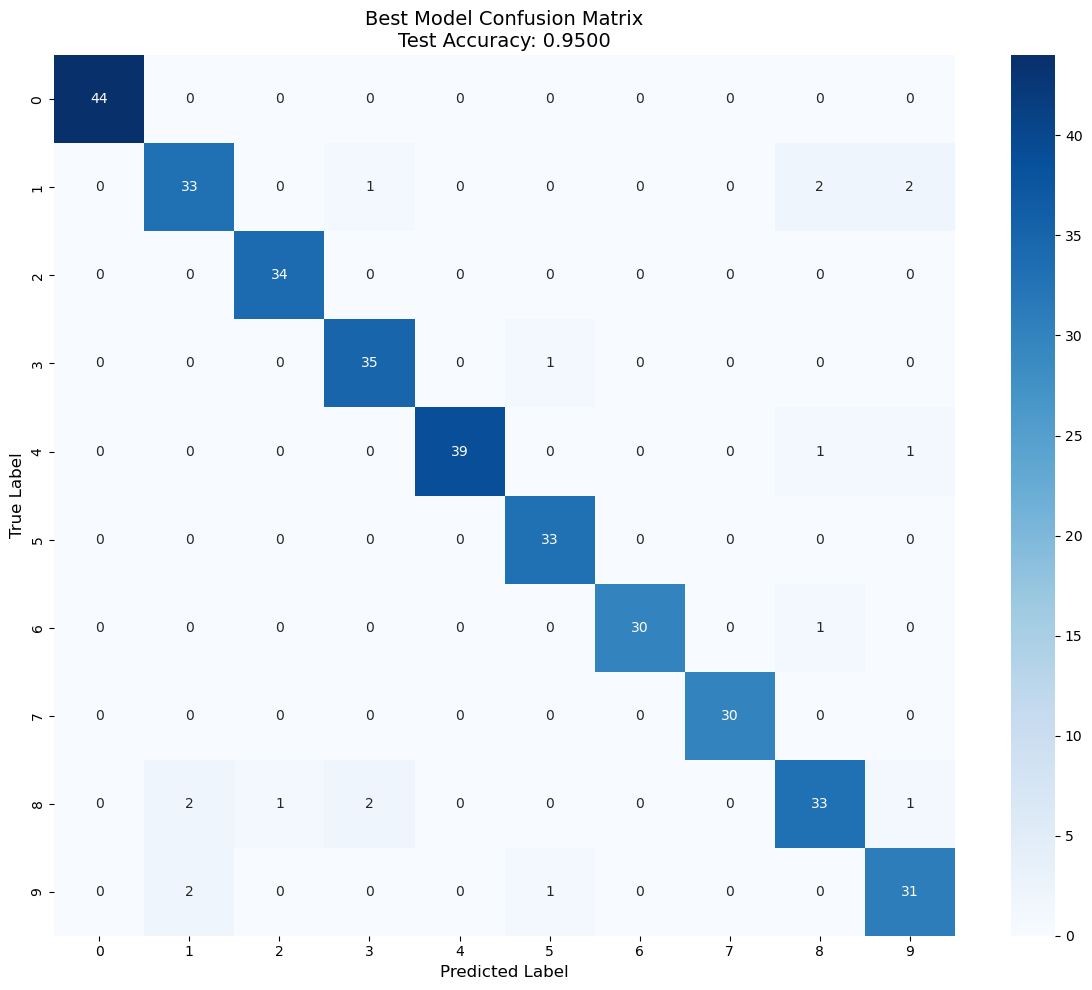

In [69]:
# Print best model confusion matrix
if best_model_exp is not None:
    y_test_pred_best = best_model_exp.predict(X_test_scaled_ones)
    cm_best = confusion_matrix(y_test.flatten(), y_test_pred_best.flatten())
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Best Model Confusion Matrix\nTest Accuracy: {best_test_acc:.4f}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [65]:
print("="*80)
print("5F. Softmax Regression - Digits Dataset: Detailed Analysis")
print("="*80)

# Get predictions
y_test_pred = best_model_exp.predict(X_test_scaled_ones)
y_train_pred = best_model_exp.predict(X_train_scaled_ones)
y_dev_pred = best_model_exp.predict(X_dev_scaled_ones)

# Calculate accuracies
train_acc = best_model_exp.score(X_train_scaled_ones, y_train)
dev_acc = best_model_exp.score(X_dev_scaled_ones, y_dev)
test_acc = best_model_exp.score(X_test_scaled_ones, y_test)

print("Dev Results Summary")
print("="*80)
print(f"  Dev Accuracy:  {dev_acc:.4f}")
print(f"  Dev Loss:      {best_model_exp.loss_history[-1]:.6f}")
print(f"  Iterations:    {len(best_model_exp.loss_history)}")

print("="*80)
print("Final Test Results")
print("="*80)
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Test Loss:     {best_model_exp.loss_history[-1]:.6f}")

# Find common digit confusions
print("\n" + "="*80)
print("Common Digit Confusions")
print("="*80)

# Analyze misclassifications
misclassifications = []
for i in range(len(y_test)):
    true_label = y_test[i].flatten()[0]
    pred_label = y_test_pred[i].flatten()[0]
    if pred_label != true_label:
        proba = best_model_exp.predict_proba(X_test_scaled_ones[i:i+1])[0]
        confidence = np.max(proba)
        misclassifications.append({
            'true': true_label,
            'pred': pred_label,
            'confidence': confidence
        })

print(f"\nTotal misclassifications: {len(misclassifications)} / {len(y_test)} ({len(misclassifications)/len(y_test)*100:.1f}%)")

# Count confusion pairs
confusion_pairs = {}
for m in misclassifications:
    pair = f"{m['true']} → {m['pred']}"
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

# Sort by frequency
sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)

print("\nMost common digit confusions (True → Predicted):")
print("-"*40)
for pair, count in sorted_pairs[:10]:
    percentage = count / len(misclassifications) * 100
    print(f"  {pair}: {count} times ({percentage:.1f}% of errors)")

# Calculate per-class metrics
print("\n" + "="*80)
print("Per-Class Performance (Test Set)")
print("="*80)
print(f"{'Digit':<8} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<8}")
print("-"*60)

from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    y_test.flatten(), y_test_pred.flatten(), average=None
)

for i in range(10):
    print(f"{i:<8} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<8}")

# Find most confusing pairs (highest off-diagonal in confusion matrix)
print("="*80)
print("Most Confusing Digit Pairs (by count)")
print("="*80)

# Get off-diagonal confusion pairs
confusion_list = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            confusion_list.append((i, j, cm[i, j]))

confusion_list.sort(key=lambda x: x[2], reverse=True)

print("\nTop 5 most confused pairs:")
for true_digit, pred_digit, count in confusion_list[:5]:
    print(f"  Digit {true_digit} misclassified as {pred_digit}: {count} times")

5F. Softmax Regression - Digits Dataset: Detailed Analysis
Dev Results Summary
  Dev Accuracy:  0.9777
  Dev Loss:      0.025380
  Iterations:    10000
Final Test Results
  Test Accuracy: 0.9500
  Test Loss:     0.025380

Common Digit Confusions

Total misclassifications: 18 / 360 (5.0%)

Most common digit confusions (True → Predicted):
----------------------------------------
  1 → 8: 2 times (11.1% of errors)
  8 → 3: 2 times (11.1% of errors)
  8 → 1: 2 times (11.1% of errors)
  9 → 1: 2 times (11.1% of errors)
  1 → 9: 2 times (11.1% of errors)
  9 → 5: 1 times (5.6% of errors)
  8 → 9: 1 times (5.6% of errors)
  3 → 5: 1 times (5.6% of errors)
  4 → 8: 1 times (5.6% of errors)
  6 → 8: 1 times (5.6% of errors)

Per-Class Performance (Test Set)
Digit    Precision    Recall       F1-Score     Support 
------------------------------------------------------------
0        1.0000       1.0000       1.0000       44      
1        0.8919       0.8684       0.8800       38      
2        

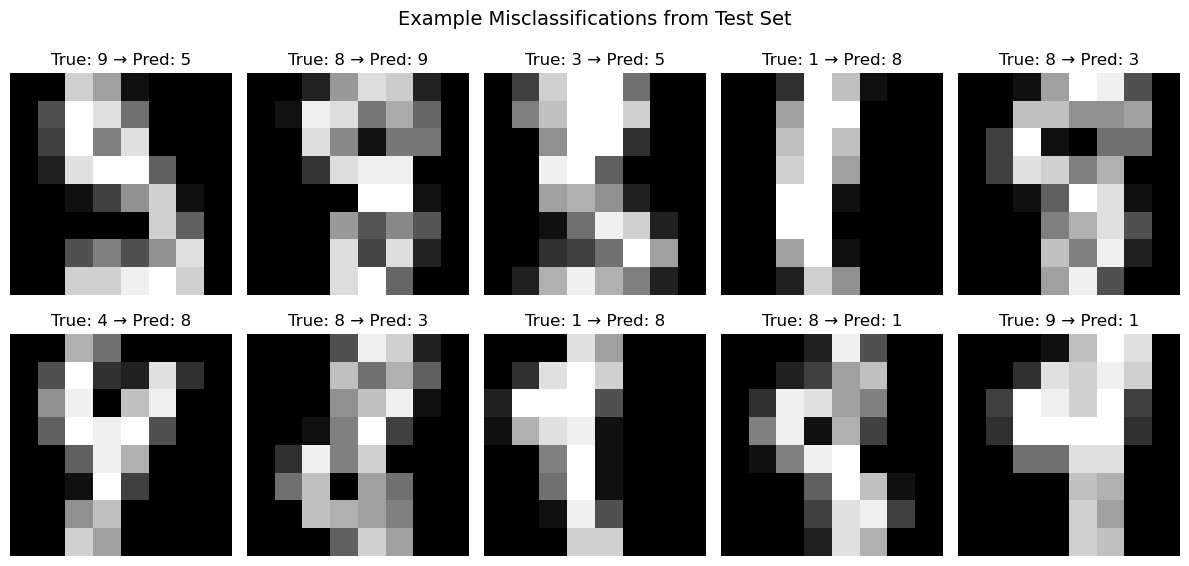


Classification Report (Test Set)
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        44
           1     0.8919    0.8684    0.8800        38
           2     0.9714    1.0000    0.9855        34
           3     0.9211    0.9722    0.9459        36
           4     1.0000    0.9512    0.9750        41
           5     0.9429    1.0000    0.9706        33
           6     1.0000    0.9677    0.9836        31
           7     1.0000    1.0000    1.0000        30
           8     0.8919    0.8462    0.8684        39
           9     0.8857    0.9118    0.8986        34

    accuracy                         0.9500       360
   macro avg     0.9505    0.9518    0.9508       360
weighted avg     0.9503    0.9500    0.9498       360



In [66]:
# Plot misclassification examples
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

# Find some example misclassifications
example_count = 0
for i in range(len(y_test)):
    if y_test[i] != y_test_pred[i] and example_count < 10:
        axes[example_count].imshow(X_test[i].reshape(8, 8), cmap='gray')
        axes[example_count].set_title(f'True: {y_test[i].item()} → Pred: {y_test_pred[i].item()}')
        axes[example_count].axis('off')
        example_count += 1

# Fill remaining subplots if needed
for i in range(example_count, 10):
    axes[i].axis('off')

plt.suptitle('Example Misclassifications from Test Set', fontsize=14)
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*80)
print("Classification Report (Test Set)")
print("="*80)
print(classification_report(y_test, y_test_pred, digits=4))

### Problem 6 — Conceptual Questions [10 pts]

Answer the following briefly, using equations when helpful.

#### Q1) Compare squared-error loss and cross-entropy loss. Why does each match its usual task?
Cross entropy loss is normalized so that makes it ideal for probabilities. It also gives a log penalty which is ideal for decisions because it severely punishes bad predictions.
\
On the other hand squared-error loss is not bounded and is quadratic which means it will be small when it is near correct. This is ideal for dancing into minima

#### Q2) What does a gradient tell us? Why does gradient descent move in the negative gradient direction?  
The gradiant tells us the direction of steepest ascent. When we do gradient descent to find minima we are looking in the direction of the steepest descent and taking a step in that direction.

#### Q3) Why can standardization help gradient descent?
Standardization perterbs the space a bit to make the curviture more uniform. This helps gradient descent converge more reliably.

#### Q4) What are train/dev/test splits for? Why should the test set be used only at the end?
The dataset is split into three batches so we can get a metric of how the model performs on data that was not used to train it. If we only used two baches then when we train the model and test it we would have no reliable way to manually turn the knobs without incorporating information from the test set. 

#### Q5) Why might logistic regression use a threshold other than $0.5$? Give an example with unequal error costs.
The threshold determines which case is more likely to be flagged incorrectly. In datasets like the cancer dataset where a false negative has much higher concequences than a false positive it would make sense to penalize them more.

### Bonus — Mini-Batch Gradient Descent [+5 pts]

Add mini-batch gradient descent to either your regression or logistic regression code. Shuffle each epoch, update after each batch, compare at least four batch sizes, plot loss versus updates, and report dev performance and runtime. Briefly discuss the trade-off between noisy updates, runtime, and model quality.

In [71]:
import time

class LinearRegressionGD:
    def __init__(self, alpha=0.1, max_iterations=10000, tolerance=1e-8, batch_size=None):
        """
        Linear Regression trained by Gradient Descent.
        
        Parameters:
        alpha: learning rate (step size)
        max_iterations: maximum number of iterations (epochs for batch)
        tolerance: stop if loss change < tolerance
        batch_size: None = full batch, 1 = SGD, >1 = mini-batch
        """
        self.alpha = alpha
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.batch_size = batch_size
        self.weights = None
        self.loss_history = []
        self.update_count = 0  # Track number of updates (not just epochs)
        
    def fit(self, X, y):
        """
        Learn weights by gradient descent with optional mini-batching.
        
        Parameters:
        X: feature matrix (n_samples, n_features) - should already include bias column
        y: target vector (n_samples, 1) - column vector
        """
        # Ensure y is a column vector
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        # Initialize weights to zeros
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        
        # For tracking updates
        self.update_count = 0
        self.loss_history = []  # Loss per update, not per epoch
        
        # Determine if using mini-batch
        use_mini_batch = self.batch_size is not None and self.batch_size < n_samples
        
        if not use_mini_batch:
            # Full-batch gradient descent (original)
            print("Using Full-Batch Gradient Descent")
            for epoch in range(self.max_iterations):
                # Compute predictions
                y_pred = X @ self.weights
                
                # Compute loss (MSE)
                loss = (1/n_samples) * np.sum((y_pred - y) ** 2)
                self.loss_history.append(loss)
                
                # Compute gradient
                gradient = (2/n_samples) * X.T @ (y_pred - y)
                
                # Update weights
                self.weights = self.weights - self.alpha * gradient
                self.update_count += 1
                
                # Check convergence
                if epoch > 0:
                    loss_change = abs(self.loss_history[-2] - self.loss_history[-1])
                    if loss_change < self.tolerance:
                        print(f"Converged after {epoch+1} epochs")
                        break
        else:
            # Mini-batch gradient descent
            print(f"Using Mini-Batch Gradient Descent (batch_size={self.batch_size})")
            
            for epoch in range(self.max_iterations):
                # Shuffle data at the beginning of each epoch
                indices = np.random.permutation(n_samples)
                X_shuffled = X[indices]
                y_shuffled = y[indices]
                
                epoch_losses = []  # Track losses within this epoch
                
                # Process mini-batches
                for start_idx in range(0, n_samples, self.batch_size):
                    end_idx = min(start_idx + self.batch_size, n_samples)
                    X_batch = X_shuffled[start_idx:end_idx]
                    y_batch = y_shuffled[start_idx:end_idx]
                    
                    batch_n = len(X_batch)
                    
                    # Compute predictions for this batch
                    y_pred_batch = X_batch @ self.weights
                    
                    # Compute loss for this batch
                    batch_loss = (1/batch_n) * np.sum((y_pred_batch - y_batch) ** 2)
                    epoch_losses.append(batch_loss)
                    
                    # Compute gradient for this batch
                    gradient = (2/batch_n) * X_batch.T @ (y_pred_batch - y_batch)
                    
                    # Update weights
                    self.weights = self.weights - self.alpha * gradient
                    self.update_count += 1
                    
                    # Store loss (per update, not per epoch)
                    self.loss_history.append(batch_loss)
                
                # Compute full loss for convergence check (optional)
                if epoch % 10 == 0:  # Check every 10 epochs
                    y_pred_full = X @ self.weights
                    full_loss = (1/n_samples) * np.sum((y_pred_full - y) ** 2)
                    
                    # Check convergence on full dataset
                    if epoch > 0:
                        if len(self.loss_history) > 1:
                            loss_change = abs(full_loss - self.loss_history[-len(epoch_losses)-1])
                            if loss_change < self.tolerance:
                                print(f"Converged after {epoch+1} epochs ({self.update_count} updates)")
                                break
        
        print(f"Final loss: {self.loss_history[-1]:.6f}")
        return self
    
    def predict(self, X):
        """Return predicted values."""
        if self.weights is None:
            raise ValueError("Must call fit() before predict()")
        return X @ self.weights
    
    def get_loss_history(self):
        """Return loss history per update."""
        return self.loss_history
    
    def get_weights(self):
        """Return learned weights."""
        return self.weights

In [74]:
print("="*80)
print("BONUS: Mini-Batch Gradient Descent Comparison")
print("="*80)

# Use the breast cancer dataset (standardized)
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load data
cancer = load_breast_cancer()
X_raw = cancer.data
y_raw = cancer.target.reshape(-1, 1)

# Split data
X_train, y_train, X_dev, y_dev, X_test, y_test = train_dev_test_split(
    X_raw, y_raw, train_ratio=0.6, dev_ratio=0.2, test_ratio=0.2, random_seed=42
)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# Add bias
X_train_ones = append_ones(X_train_scaled)
X_dev_ones = append_ones(X_dev_scaled)
X_test_ones = append_ones(X_test_scaled)

print(f"\nDataset shape: {X_train_ones.shape}")
print(f"Total training samples: {X_train_ones.shape[0]}")

# Define batch sizes to test (including full batch)
batch_sizes = [None, 256, 128, 64, 32, 16, 8, 4, 2, 1]
# None = full batch

results = []

print("\n" + "="*80)
print(f"{'Batch Size':<12} {'Updates':<12} {'Time (s)':<12} {'Dev MSE':<12} {'Status':<15}")
print("-"*80)

for batch_size in batch_sizes:
    # Skip if batch_size > dataset size
    if batch_size and batch_size > X_train_ones.shape[0]:
        continue
        
    # Display name
    batch_name = "Full" if batch_size is None else batch_size
    
    # Create and train model
    model = LinearRegressionGD(
        alpha=0.01, 
        max_iterations=100,  # epochs for mini-batch
        tolerance=1e-8,
        batch_size=batch_size
    )
    
    # Time the training
    start_time = time.time()
    model.fit(X_train_ones, y_train)
    end_time = time.time()
    train_time = end_time - start_time
    
    # Get dev MSE
    y_dev_pred = model.predict(X_dev_ones)
    dev_mse = np.mean((y_dev_pred - y_dev) ** 2)
    
    # Store results
    results.append({
        'batch_size': batch_name,
        'updates': model.update_count,
        'time': train_time,
        'dev_mse': dev_mse,
        'loss_history': model.get_loss_history(),
        'model': model
    })
    
    status = "Converged" if model.update_count < model.max_iterations else "Max iter"
    print(f"{batch_name:<12} {model.update_count:<12} {train_time:<12.4f} {dev_mse:<12.6f} {status:<15}")

print("="*80)

BONUS: Mini-Batch Gradient Descent Comparison

Dataset shape: (341, 31)
Total training samples: 341

Batch Size   Updates      Time (s)     Dev MSE      Status         
--------------------------------------------------------------------------------
Using Full-Batch Gradient Descent
Final loss: 0.068775
Full         100          0.0173       0.060130     Max iter       
Using Mini-Batch Gradient Descent (batch_size=256)
Final loss: 0.057001
256          200          0.0492       0.056479     Max iter       
Using Mini-Batch Gradient Descent (batch_size=128)
Final loss: 0.056932
128          300          0.0111       0.057185     Max iter       
Using Mini-Batch Gradient Descent (batch_size=64)
Final loss: 0.051352
64           600          0.0197       0.056984     Max iter       
Using Mini-Batch Gradient Descent (batch_size=32)
Final loss: 0.077224
32           1100         0.0923       0.056139     Max iter       
Using Mini-Batch Gradient Descent (batch_size=16)
Final loss: 0.04461

In [75]:
print("="*80)
print("BONUS: Mini-Batch Gradient Descent Comparison")
print("="*80)

# Use the breast cancer dataset (standardized)
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load data
cancer = load_breast_cancer()
X_raw = cancer.data
y_raw = cancer.target.reshape(-1, 1)

# Split data
X_train, y_train, X_dev, y_dev, X_test, y_test = train_dev_test_split(
    X_raw, y_raw, train_ratio=0.6, dev_ratio=0.2, test_ratio=0.2, random_seed=42
)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# Add bias
X_train_ones = append_ones(X_train_scaled)
X_dev_ones = append_ones(X_dev_scaled)
X_test_ones = append_ones(X_test_scaled)

print(f"\nDataset shape: {X_train_ones.shape}")
print(f"Total training samples: {X_train_ones.shape[0]}")

# Define batch sizes to test (including full batch)
batch_sizes = [None, 256, 128, 64, 32, 16, 8, 4, 2, 1]
# None = full batch

results = []

print("\n" + "="*80)
print(f"{'Batch Size':<12} {'Updates':<12} {'Time (s)':<12} {'Dev MSE':<12} {'Status':<15}")
print("-"*80)

for batch_size in batch_sizes:
    # Skip if batch_size > dataset size
    if batch_size and batch_size > X_train_ones.shape[0]:
        continue
        
    # Display name
    batch_name = "Full" if batch_size is None else batch_size
    
    # Create and train model
    model = LinearRegressionGD(
        alpha=0.01, 
        max_iterations=100,  # epochs for mini-batch
        tolerance=1e-8,
        batch_size=batch_size
    )
    
    # Time the training
    start_time = time.time()
    model.fit(X_train_ones, y_train)
    end_time = time.time()
    train_time = end_time - start_time
    
    # Get dev MSE
    y_dev_pred = model.predict(X_dev_ones)
    dev_mse = np.mean((y_dev_pred - y_dev) ** 2)
    
    # Store results
    results.append({
        'batch_size': batch_name,
        'updates': model.update_count,
        'time': train_time,
        'dev_mse': dev_mse,
        'loss_history': model.get_loss_history(),
        'model': model
    })
    
    status = "Converged" if model.update_count < model.max_iterations else "Max iter"
    print(f"{batch_name:<12} {model.update_count:<12} {train_time:<12.4f} {dev_mse:<12.6f} {status:<15}")

print("="*80)

BONUS: Mini-Batch Gradient Descent Comparison

Dataset shape: (341, 31)
Total training samples: 341

Batch Size   Updates      Time (s)     Dev MSE      Status         
--------------------------------------------------------------------------------
Using Full-Batch Gradient Descent
Final loss: 0.068775
Full         100          0.0135       0.060130     Max iter       
Using Mini-Batch Gradient Descent (batch_size=256)
Final loss: 0.057001
256          200          0.0547       0.056479     Max iter       
Using Mini-Batch Gradient Descent (batch_size=128)
Final loss: 0.056932
128          300          0.0277       0.057185     Max iter       
Using Mini-Batch Gradient Descent (batch_size=64)
Final loss: 0.051352
64           600          0.0398       0.056984     Max iter       
Using Mini-Batch Gradient Descent (batch_size=32)
Final loss: 0.077224
32           1100         0.1345       0.056139     Max iter       
Using Mini-Batch Gradient Descent (batch_size=16)
Final loss: 0.04461

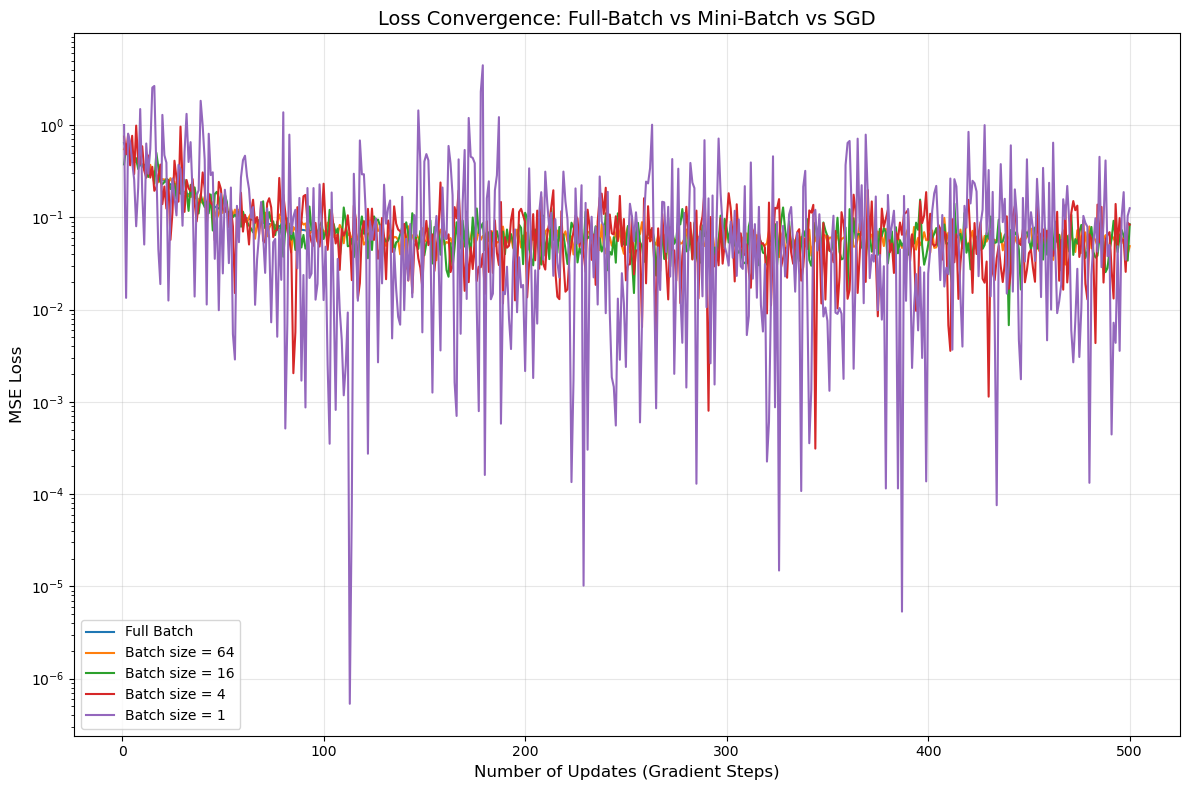

In [76]:
# Plot loss curves for at least 4 batch sizes
plot_sizes = ['Full', 64, 16, 4, 1]  # Full batch, medium, small, mini, SGD

plt.figure(figsize=(12, 8))

for size in plot_sizes:
    result = next((r for r in results if str(r['batch_size']) == str(size)), None)
    if result:
        loss_history = result['loss_history']
        updates = range(1, len(loss_history) + 1)
        
        # Only plot first few updates for clarity
        plot_updates = updates[:500]
        plot_losses = loss_history[:500]
        
        label = f"Batch size = {size}" if size != 'Full' else "Full Batch"
        plt.plot(plot_updates, plot_losses, linewidth=1.5, label=label)

plt.xlabel('Number of Updates (Gradient Steps)', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Loss Convergence: Full-Batch vs Mini-Batch vs SGD', fontsize=14)
plt.yscale('log')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
print("\n" + "="*80)
print("Detailed Comparison")
print("="*80)

# Create summary table
print(f"\n{'Batch Size':<12} {'Updates':<12} {'Time (s)':<12} {'Dev MSE':<12} {'Updates/sec':<12}")
print("-"*70)

for r in results:
    updates_per_sec = r['updates'] / r['time'] if r['time'] > 0 else 0
    print(f"{r['batch_size']:<12} {r['updates']:<12} {r['time']:<12.4f} {r['dev_mse']:<12.6f} {updates_per_sec:<12.2f}")

print("="*80)

# Find best model by dev MSE
best_result = min(results, key=lambda x: x['dev_mse'])
print(f"\n✓ Best performing model: Batch size = {best_result['batch_size']}")
print(f"  Dev MSE: {best_result['dev_mse']:.6f}")
print(f"  Updates: {best_result['updates']}")
print(f"  Time: {best_result['time']:.4f} seconds")

# Fastest converging model
fastest = min(results, key=lambda x: x['time'])
print(f"\n⚡ Fastest to converge: Batch size = {fastest['batch_size']}")
print(f"  Time: {fastest['time']:.4f} seconds")
print(f"  Dev MSE: {fastest['dev_mse']:.6f}")


Detailed Comparison

Batch Size   Updates      Time (s)     Dev MSE      Updates/sec 
----------------------------------------------------------------------
Full         100          0.0135       0.060130     7428.15     
256          200          0.0547       0.056479     3658.75     
128          300          0.0277       0.057185     10839.96    
64           600          0.0398       0.056984     15078.48    
32           1100         0.1345       0.056139     8176.89     
16           2200         0.0638       0.057890     34480.39    
8            4300         0.2250       0.053633     19111.32    
4            8600         0.2392       0.056789     35947.75    
2            17100        0.7745       0.075013     22079.14    
1            34100        1.3612       0.081900     25051.45    

✓ Best performing model: Batch size = 8
  Dev MSE: 0.053633
  Updates: 4300
  Time: 0.2250 seconds

⚡ Fastest to converge: Batch size = Full
  Time: 0.0135 seconds
  Dev MSE: 0.060130


<Figure size 1000x600 with 0 Axes>

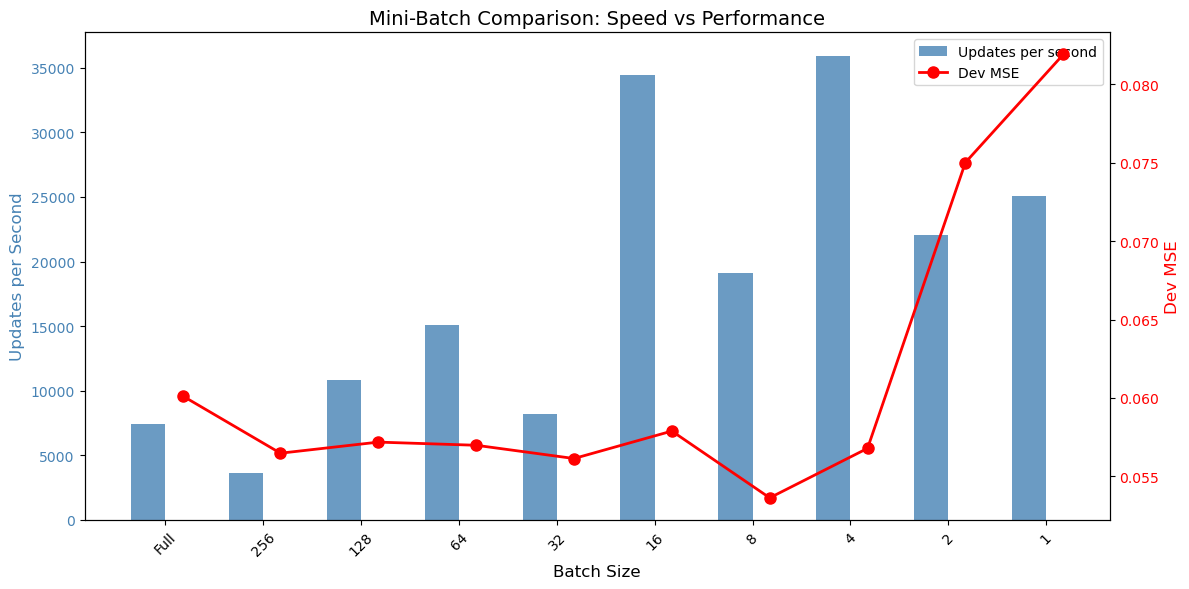

In [78]:
plt.figure(figsize=(10, 6))

batch_sizes_plot = [str(r['batch_size']) for r in results]
updates_per_sec = [r['updates'] / r['time'] if r['time'] > 0 else 0 for r in results]
dev_mses = [r['dev_mse'] for r in results]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for updates per second
x = np.arange(len(batch_sizes_plot))
width = 0.35

bars1 = ax1.bar(x - width/2, updates_per_sec, width, label='Updates per second', color='steelblue', alpha=0.8)
ax1.set_xlabel('Batch Size', fontsize=12)
ax1.set_ylabel('Updates per Second', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line for dev MSE
ax2 = ax1.twinx()
line2 = ax2.plot(x + width/2, dev_mses, 'r-o', label='Dev MSE', linewidth=2, markersize=8)
ax2.set_ylabel('Dev MSE', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Customize x-axis
ax1.set_xticks(x)
ax1.set_xticklabels(batch_sizes_plot, rotation=45)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Mini-Batch Comparison: Speed vs Performance', fontsize=14)
plt.tight_layout()
plt.show()

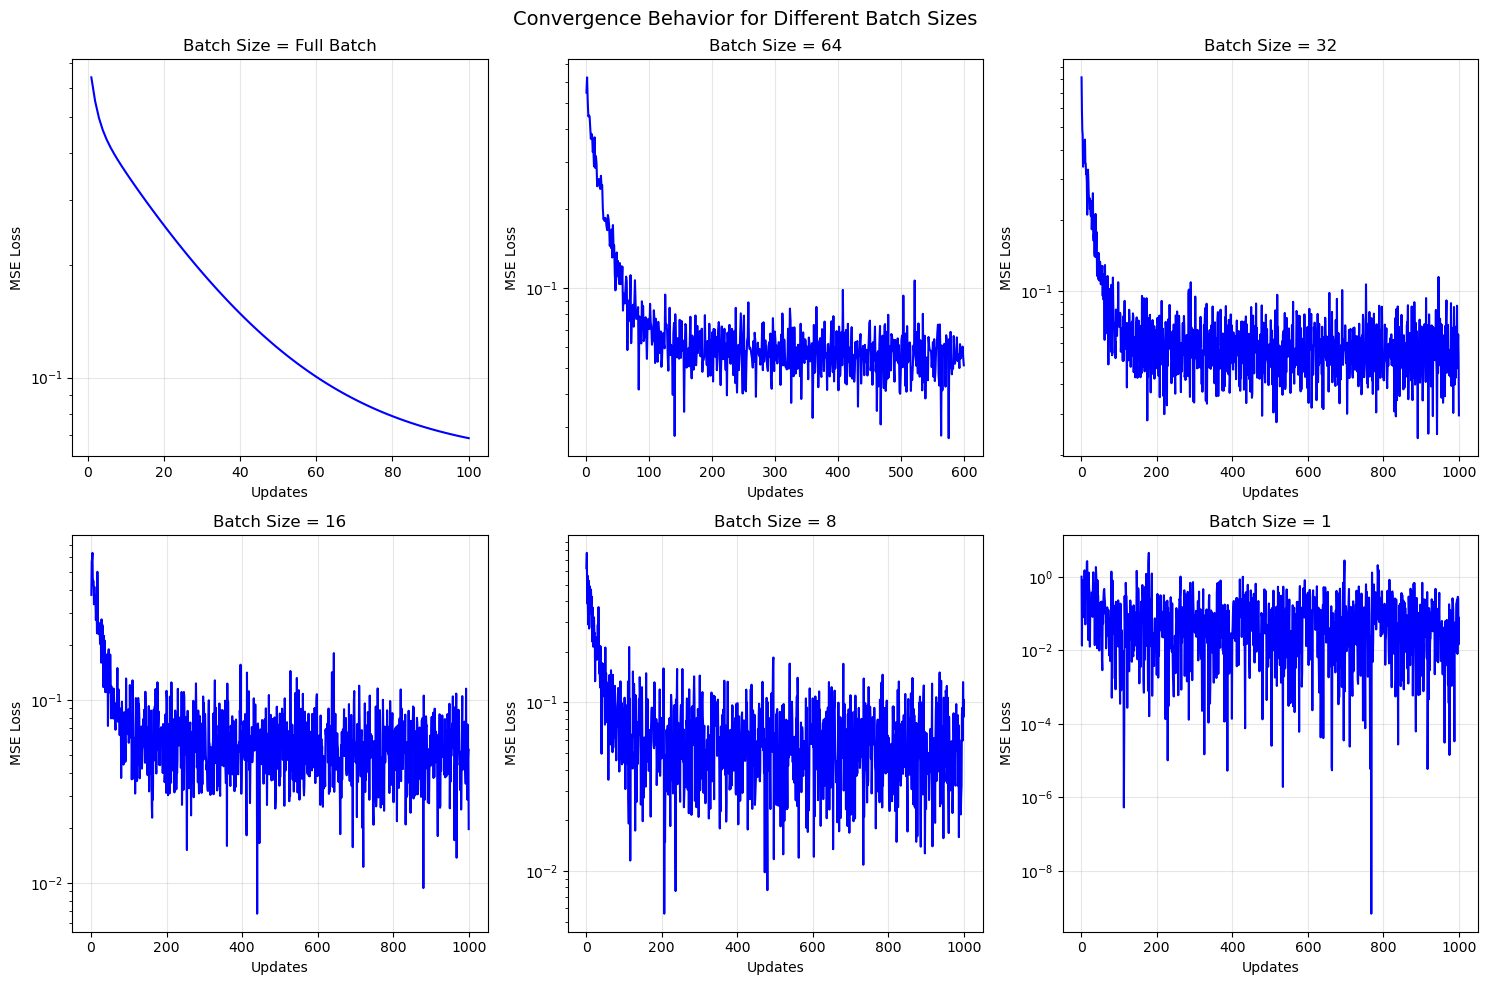

In [79]:
# Create subplots for different batch sizes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_sizes_sub = ['Full', 64, 32, 16, 8, 1]

for idx, size in enumerate(plot_sizes_sub):
    result = next((r for r in results if str(r['batch_size']) == str(size)), None)
    if result:
        loss_history = result['loss_history']
        updates = range(1, len(loss_history) + 1)
        
        axes[idx].plot(updates[:1000], loss_history[:1000], 'b-', linewidth=1.5)
        axes[idx].set_xlabel('Updates')
        axes[idx].set_ylabel('MSE Loss')
        axes[idx].set_title(f'Batch Size = {size if size != "Full" else "Full Batch"}')
        axes[idx].set_yscale('log')
        axes[idx].grid(True, alpha=0.3)

plt.suptitle('Convergence Behavior for Different Batch Sizes', fontsize=14)
plt.tight_layout()
plt.show()